<a href="https://www.kaggle.com/code/vladosht/simple-stock-pricing-model?scriptVersionId=293431516" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

This notebook will present a model which attempts to make individual estimates whether a stock is undervalued or not. It is based on the fundamental financial data of 3000+ public companies, which report to the SEC and which are currently traded on US stock exchanges.

DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.

In [1]:
import torch
import json
import multiprocessing as mp
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, preprocessing
#pd.set_option('display.max_rows', 200)
# Workaround for a pandas bug, as described here:
# https://stackoverflow.com/questions/30519487/pandas-error-invalid-value-encountered
#pd.set_option('display.float_format', lambda x:'%f'%x)

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Torch threads:',torch.get_num_threads())
print(torch.ones(1, device=device),device)

Torch threads: 2
tensor([1.], device='cuda:0') cuda


In [3]:
if __name__ == '__main__':
    mp.set_start_method('fork')
print('{} CPUs available'.format(mp.cpu_count()))
max_jobs = mp.cpu_count() + 1

4 CPUs available


The model will be based on the following features and labels, taken from the SEC fundamentals dataset:

In [4]:
ml_features = ['Assets','Liabilities','NetCashOperating_ttm']
ml_label = 'price'
keys = ['snapshot','cik','date']
window_size = 12*3 #in number of snapshots

The model is called "simple", because it is rooted in this very basic assumption:  
Market_Capitalization = ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) \* hype + bias  
The business logic behind this formula is that the market capitalization of a company is dependent on its current static value (its equity) and its future cashflows. The following considerations apply:  
1. We assume the total assets of an individual company should never be taken at the nominal value that appears on the balance sheet, because they often contain a significant amount of "intangible" assets, for which it is notoriously difficult to arrive at a fair value. Therefore, we discount them with an asset_multiplier.
2. Liabilities, on the other hand, can be taken at nominal value, because it is a rare event for any kind of debt, accounts payable or the like, to be written off.
3. Then, the cash flows from operating activities can be modeled as a [perpetuity](https://en.wikipedia.org/wiki/Perpetuity). This is inspired by the idea for a [Steady State Cash Flow Model](https://www.google.com/search?q=%22Steady+State+Cash+Flow+Model%22) where we attempt to estimate the fair value of a company on the assumption that its business behaves the same way for the foreseeable future. In essence, we again discount the NetCashOperating_ttm with a cash_multiplier. We use the Trailing Twelve Months (ttm) value here, and not the quarterly value, because it smoothens any seasonalities and makes the model less erratic.
4. All of the above is multiplied by a "hype" parameter, which is the premium or penalty that the market gives to the total value of the company.
5. The bias further fine-tunes the company value to its market capitalization.  

However, it seems difficult to obtain freely available historic market capitalization data for individual companies. It turns out this is not really necessary. It is much easier to obtain historic prices and modelling the share price directly is even simpler.  
We do this by maximizing the **correlation coefficient** between our formula and the price. In short, we try to find such asset_multiplier and cash_multiplier parameters, for which the correlation between ( Assets \* asset_multiplier - Liabilities + NetCashOperating_ttm \* cash_multiplier ) and the price is equal to 1.

In [5]:
# We use this dataset to provide ticker descriptions later on.
with open('/kaggle/input/sec-edgar-cik-ticker-exchange/company_tickers_exchange.json',mode='rt') as f:
    jfile = json.load(f)
tickers = pd.DataFrame(columns=jfile['fields'],data=jfile['data'],dtype=str)
tickers = tickers[tickers['exchange']!='OTC'].dropna() #leave only tickers traded on an exchange
tickers['exchange'] = tickers['exchange'].str.upper().str.strip()
tickers['cik'] = tickers['cik'].str.zfill(10)
tickers['len'] = 4
tickers.loc[tickers[tickers['ticker'].str.contains('-')].index,'len'] += 1
tickers['ticker'] = tickers.apply(lambda row: str(row.ticker[:row.len]),axis='columns').str.rstrip().str.rstrip('-').str.upper()
tickers = tickers.sort_values(by=['cik','exchange','ticker']).drop_duplicates(subset=['cik'],keep='last').set_index('cik').drop(columns=['len'])
tickers

,name,ticker,exchange
cik,,,
0000001750,AAR CORP,AIR,NYSE
0000001800,ABBOTT LABORATORIES,ABT,NYSE
0000002098,ACME UNITED CORP,ACU,NYSE
0000002178,"ADAMS RESOURCES & ENERGY, INC.",AE,NYSE
0000002186,BK Technologies Corp,BKTI,NYSE
...,...,...,...
0001984060,Atlas Energy Solutions Inc.,AESI,NYSE
0001990550,"Ambrx Biopharma, Inc.",AMAM,NASDAQ
0001993004,"NorthWestern Energy Group, Inc.",NWE,NASDAQ


In [6]:
prices = pd.read_csv('/kaggle/input/monthly-us-stock-prices/prices.csv').rename(columns={'date':'snapshot'}).dropna()
prices['snapshot'] = pd.to_datetime(prices['snapshot']).dt.date
prices

,ticker,exchange,snapshot,price
0,A,NYSE - Delayed Quote,2010-02-01,20.05
1,A,NYSE - Delayed Quote,2010-03-01,22.50
2,A,NYSE - Delayed Quote,2010-04-01,24.60
3,A,NYSE - Delayed Quote,2010-05-01,25.94
4,A,NYSE - Delayed Quote,2010-06-01,23.15
...,...,...,...,...
604455,ZYME,NasdaqGS - Delayed Quote,2025-09-01,14.81
604456,ZYME,NasdaqGS - Delayed Quote,2025-10-01,17.08
604457,ZYME,NasdaqGS - Delayed Quote,2025-11-01,19.08
604458,ZYME,NasdaqGS - Delayed Quote,2025-12-01,26.71


In [7]:
raw_snapshots = pd.read_csv('/kaggle/input/fundamental-data-from-sec-xbrl-companyfacts-zip/snapshots.csv',dtype={'cik':str})
for i in ['snapshot','date']:
    raw_snapshots[i] = pd.to_datetime(raw_snapshots[i]).dt.date
raw_snapshots['timediff'] = pd.to_timedelta((raw_snapshots['snapshot'] - raw_snapshots['date'])).dt.days
raw_snapshots

,snapshot,cik,date,Assets,Revenue,COGS,GrossProfit,Equity,NetCashOperating,NetCashFinancing,...,Revenue_ttm,GrossProfit_ttm,NetCashOperating_ttm,NetCashFinancing_ttm,Earnings_ttm,ticker,exchange,PublicFloat,Employees,timediff
0,2012-01-01,0000001750,2011-11-30,1.821612,0.482000,0.403400,0.078600,0.863948,0.030412,-0.006559,...,1.920517,0.322328,0.083588,0.026485,0.073512,AIR,NYSE,0.934568,NaN,32
1,2012-01-01,0000001800,2011-09-30,59.628176,9.816682,3.973250,5.843432,24.603800,3.054430,-2.668122,...,38.441677,22.693948,9.885247,-4.831951,4.550604,ABT,NYSE,69.683329,NaN,93
2,2012-01-01,0000001961,2011-09-30,NaN,0.000000,0.000000,0.000000,NaN,-0.000067,0.000150,...,0.000188,0.000169,-0.000528,0.000456,-0.000968,NaN,NaN,NaN,NaN,93
3,2012-01-01,0000002034,2011-09-30,0.292355,0.101317,0.082798,0.018519,0.161372,0.005913,-0.001570,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93
4,2012-01-01,0000002098,2011-09-30,0.055344,0.019036,0.012396,0.006640,0.027561,0.003165,-0.000680,...,0.093494,0.033742,-0.003533,0.008428,0.004770,ACU,NYSE,NaN,NaN,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089969,2026-01-17,0002081125,2025-09-30,0.000472,NaN,NaN,NaN,-0.000040,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,DNMX,NASDAQ,NaN,NaN,109
1089970,2026-01-17,0002081628,2025-09-30,0.000002,0.000000,NaN,NaN,0.000002,0.000000,0.000002,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,109
1089971,2026-01-17,0002082542,2025-09-30,0.000225,NaN,NaN,NaN,-0.000017,-0.000027,0.000064,...,NaN,NaN,NaN,NaN,NaN,BIXI,NASDAQ,NaN,NaN,109
1089972,2026-01-17,0002082844,2025-09-30,0.000197,NaN,NaN,NaN,-0.000034,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,SAC-U,NYSE,NaN,NaN,109


Below we merge the fundamental data with the price data and do some dataset cleaning to maximize model performance. The datasets themselves are documented on their respective pages and you can refer to them for further insights about their structure.

In [8]:
snapshots = pd.merge(raw_snapshots,prices,on=['ticker','snapshot'],suffixes=('','_yahoo'),how='left')

# The key date (snapshot date) must always be later than the period-end date. We enforce this
# per cik using the timediff column - it must be positive for all records of a cik.
# We also ensure a window_size number of snapshots of historic data is available for each cik.
snapshots = snapshots[keys +['ticker'] + ml_features + [ml_label] + ['timediff']]
valid_ciks = snapshots.dropna().groupby(by='cik')['timediff'].aggregate(['min','count'])
valid_ciks = valid_ciks[(valid_ciks['min']>0)&(valid_ciks['count']>window_size)]
snapshots = snapshots.set_index(keys)
snapshots = snapshots.loc[(slice(None),valid_ciks.index.to_list()),:].sort_index().drop(columns='timediff')

# Ciks that have assets close to zero cause problems during training. We remove them
zero_asset_ciks = list(snapshots[snapshots['Assets'].fillna(0.0).abs()<1e-3].reset_index()['cik'].unique())
zero_asset_ciks = snapshots.loc[(slice(None),zero_asset_ciks),:].index
snapshots = snapshots.drop(index=zero_asset_ciks)

# There are several ciks, that have reported wrong data 1000 times larger than actual.
# They apparently never submitted a correction.
# This data disrupts the training and we remove the whole ciks.
asset_outliers = snapshots.groupby(by='cik')['Assets'].aggregate(['min','max'])
asset_outliers = asset_outliers['min']/asset_outliers['max']
asset_outliers = asset_outliers.sort_values().fillna(0.0)
asset_outliers = list(asset_outliers[asset_outliers<1e-3].reset_index()['cik'].unique())
asset_outliers = snapshots.loc[(slice(None),asset_outliers),:].index
snapshots = snapshots.drop(index=asset_outliers)
snapshots

ticker     Assets  Liabilities  \
snapshot   cik        date                                        
2012-01-01 0000001750 2011-11-30    AIR   1.821612     0.957664   
           0000001800 2011-09-30    ABT  59.628176    35.024376   
           0000002098 2011-09-30    ACU   0.055344     0.027783   
           0000002488 2011-10-01    AMD   5.236000     3.492000   
           0000002969 2011-09-30    APD  14.290700     8.494900   
...                                 ...        ...          ...   
2026-01-17 0001905956 2025-09-30    TGL   0.016595     0.004622   
           0001906324 2025-09-28   QDEL   5.675100     3.638700   
           0001907982 2025-09-30   QBTS   0.865820     0.195266   
           0001914605 2025-09-30   ECBK   1.552653     1.383344   
           0001915657 2025-09-30   DINO  17.264000     7.834000   

                                  NetCashOperating_ttm  price  
snapshot   cik        date                                     
2012-01-01 0000001750 2011-11-30              0.083588  19.17  
           0000001800 2011-09-30              9.885247  26.98  
           0000002098 2011-09-30             -0.003533   9.50  
           0000002488 2011-10-01             -0.018000   5.40  
           0000002969 2011-09-30              1.753200  78.81  
...                                                ...    ...  
2026-01-17 0001905956 2025-09-30             -0.010266    NaN  
           0001906324 2025-09-28              0.037000    NaN  
           0001907982 2025-09-30             -0.051593    NaN  
           0001914605 2025-09-30              0.009768    NaN  
           0001915657 2025-09-30              1.167000    NaN  

[456783 rows x 5 columns]

Machine learning algorithms in general cannot handle NaN values. The data we feed into our algorithm later must not only be free of NaNs, but it must also be symmetrical, i.e., for each cik there must be the same number of snapshots in the dataset. This is of course not the case in the raw data, so we create rows where they do not exist for a particular cik/snapshot combination. Then we replace all NaNs with zero, but we do retain information in a new column (is_created) whether a row was artificially created or not.

In [9]:
ml_input_df = snapshots.dropna().copy()
ml_input_df['is_created'] = False
unique_snapshot_dates = ml_input_df.index.get_level_values(0).unique().sort_values().to_series()
unique_ciks = ml_input_df.index.get_level_values(1).unique().sort_values().to_series()
print("There are {} unique snapshots and {} unique ciks for a total of {} records.".format(
    len(unique_snapshot_dates),len(unique_ciks),len(unique_snapshot_dates)*len(unique_ciks)))

ml_input_df = pd.merge(pd.merge(unique_snapshot_dates, unique_ciks, how='cross'),
                       ml_input_df[ml_features+[ml_label,'is_created']].reset_index(drop=False),how='left')
ml_input_df = ml_input_df.drop(columns=['date']).set_index(['cik','snapshot']).sort_index()
ml_input_df['is_created'] = ml_input_df['is_created'].isna()
ml_input_df = ml_input_df.fillna(0.0)
ml_input_df

There are 169 unique snapshots and 3398 unique ciks for a total of 574262 records.


Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                       is_created  
cik        snapshot                
0000001750 2012-01-01       False  
           2012-02-01       False  
           2012-03-01       False  
           2012-04-01       False  
           2012-05-01       False  
...                           ...  
0001915657 2025-09-01       False  
           2025-10-01       False  
           2025-11-01       False  
           2025-12-01       False  
           2026-01-01       False  

[574262 rows x 5 columns]

The cell below is the heart of our machine learning model. The following is critical for the loss function we want to use - the correlation coefficient between our model formula and the price. Unfortunately the built-in PyTorch function can handle only pairs of 1d tensors, so with the help of Gemini we re-created it to handle our multi-dimensional data.

In [10]:
# Generated by Gemini AI
def batched_corrcoef(t1, t2):
    """
    Computes batched correlation coefficient matrix.
    t1 and t2 are tensors of shape (B, N) where B is the batch size
    and N is the number of observations.
    Returns a tensor of shape (B, 2, 2).
    """
    # Stack the tensors along a new dimension to create a (B, 2, N) tensor
    stacked_tensors = torch.stack([t1, t2], dim=1)

    # Compute covariance for each batch
    # We need to compute covariance for each item in the batch.
    # torch.cov doesn't have a batch dimension argument.
    # We can implement batched covariance manually.
    mean_x = torch.mean(stacked_tensors, dim=2, keepdim=True)
    mx = stacked_tensors - mean_x
    # For batched dot product, we can use matmul
    # mx is (B, 2, N), mx.transpose(-1, -2) is (B, N, 2)
    # cov is (B, 2, 2)
    cov_matrix = torch.matmul(mx, mx.transpose(-1, -2)) / (stacked_tensors.size(2) - 1)

    # Extract diagonal for standard deviation
    std_dev = torch.sqrt(torch.diagonal(cov_matrix, dim1=-2, dim2=-1))
    # std_dev is (B, 2). We need to compute outer product for each batch item.
    # We can do this by unsqueezing and multiplying.
    std_dev_prod = std_dev.unsqueeze(2) * std_dev.unsqueeze(1)

    # Normalize covariance matrix
    corr_matrix = cov_matrix / std_dev_prod
    return corr_matrix

# Create two sample tensors
t1 = torch.randn(10, 5)
t2 = torch.randn(10, 5)

# Compute batched correlation coefficient
result_vectorized = batched_corrcoef(t1, t2)

print("Shape of the vectorized result:", result_vectorized.shape)
print("Result for the first batch item (vectorized):\n", result_vectorized[0])

Shape of the vectorized result: torch.Size([10, 2, 2])
Result for the first batch item (vectorized):
 tensor([[1.0000, 0.0180],
        [0.0180, 1.0000]])


In [11]:
# The correlation coefficient varies from 0 (no correlation) to 1 (perfect correlation)
# In order to be used as a part of a loss function, we have to convert this in a way
# that 0 means perfect correlation.
def convert_corrcoef_to_loss(corrcoef):
    """
    Takes a tensor of shape (B, 2, 2).
    """
    return 2 - corrcoef.sum(dim=[1,2])/2

What follows is the actual model implementation. We need to clarify several things here:
1. We compute the asset_multiplier on per-cik basis, but the cash_multiplier is only computed on per-snapshot basis. The reasoning behind this is that it is much more logical to assume that the discount rate for the NetCashOperating_ttm is the same for all ciks on a given date, something like a common interest rate for all companies that depends not on individual companies, but on general interest and inflation levels and return-on-investment expectations of investors. This also makes the model more generalized.
2. The asset_multiplier is enforced to be always positive by exponentiating the actual parameter we are trying to find. I.e., final asset_multiplier = 10 \*\* (internal parameter)
3. From our previous [whole-market model](https://www.kaggle.com/code/vladosht/s-p-500-fundamental-data-model) we know that the market as a whole does not adjust the total assets away from their nominal value. We put this knowledge into the loss function by minimizing the ratio between total adjusted assets for all ciks and total unadjusted assets for all ciks (method get_asset_loss)
4. Finally, the model results are returned by the get_df method, which simply takes the input dataframe and extends it with two additional columns for the asset_multiplier and cash_multiplier. It also returns a column for the computed model value. Remember, this model value only correlates well with the price, it is not equal to the price.

In [12]:
class SimplePricingModel(torch.nn.Module):
    def __init__(self,df):
        super().__init__()
        self.df          = df
        self.columns     = df.columns.to_list()
        self.columns     = { i:self.columns.index(i) for i in self.columns }
        self.ciks        = df.index.get_level_values(0).unique()
        self.len_ciks    = len(self.ciks)
        self.len_snapshots = len(df.index.get_level_values(1).unique())
        self.asmul       = torch.nn.Parameter(0.1 + torch.rand(self.len_ciks))
        self.cashmul     = torch.nn.Parameter(0.1 + torch.rand(self.len_snapshots))
        self.ml_input    = torch.nn.Buffer(torch.tensor(df[ml_features].to_numpy()).reshape(self.len_ciks,self.len_snapshots,-1))
        self.labels      = torch.nn.Buffer(torch.tensor(df[ml_label].to_numpy()).reshape(self.len_ciks,self.len_snapshots))
        self.print_shape = True
        print('Input shape:',self.ml_input.shape)
        print('Labels shape:',self.labels.shape)
        print('Asset multiplier shape:',self.asmul.shape)
        print('Cash multiplier shape:',self.cashmul.shape)

    def get_adjusted_assets(self):
        adjusted_assets = self.ml_input[:,:,self.columns['Assets']] * 10**self.asmul.unsqueeze(1)
        if self.print_shape:
            print('Adjusted assets shape:',adjusted_assets.shape)        
        return adjusted_assets

    def get_asset_loss(self):
        # 1d tensor of length self.len_snapshots
        asset_loss = (self.get_adjusted_assets().sum(dim=0)/self.ml_input[:,:,self.columns['Assets']].sum(dim=0)-1)**2
        if self.print_shape:
            print('Asset loss shape:',asset_loss.shape)        
        return asset_loss
    
    def get_total_loss(self):
        y_pred = self()
        corrcoef = batched_corrcoef(y_pred,self.labels)
        if self.print_shape:
            print('Predictions shape:',y_pred.shape)
            print('Labels shape:',self.labels.shape)
            print('Correlation coefficient shape:',corrcoef.shape)
        corrcoef = convert_corrcoef_to_loss(corrcoef)
        total_loss = corrcoef.sum() + corrcoef.std()
        # We need regularization for the asset_multiplier, otherwise the values become uncomparable across ciks
        total_loss += 100 * (self.asmul.mean()**2)**0.5 + 10 * self.asmul.std()
        total_loss += self.get_asset_loss().sum()
        if self.print_shape:
            self.print_shape = False
        return total_loss

    def get_param_state(self):
        return { "median cashmul" : self.cashmul.median().item(), "median asmul" : (10 ** self.asmul).median().item() }

    def forward(self):
        fwd = self.get_adjusted_assets()
        fwd -= self.ml_input[:,:,self.columns['Liabilities']]
        fwd += self.ml_input[:,:,self.columns['NetCashOperating_ttm']] * self.cashmul.unsqueeze(0)
        if self.print_shape:
            print('Forward shape:',fwd.shape)
        return fwd

    def get_df(self):
        ret_df = self.df.copy()
        asmul = pd.Series(index=self.ciks, data = self.asmul.reshape(-1).cpu().detach().numpy()).rename('asmul')
        asmul = 10**asmul
        cashmul = self.cashmul.cpu().detach().numpy()
        cashmul = pd.Series(index=self.df.index.get_level_values(1).unique().sort_values(), data=cashmul).rename('cashmul')

        ret_df = pd.merge(ret_df,asmul,left_index=True,right_index=True)
        ret_df = pd.merge(ret_df,cashmul,left_index=True,right_index=True)
        ret_df['model'] = self.forward().reshape(-1).cpu().detach().numpy()
        return ret_df

pricing_model = SimplePricingModel(ml_input_df).to(device)
print(pricing_model.ml_input.device)

Input shape: torch.Size([3398, 169, 3])
Labels shape: torch.Size([3398, 169])
Asset multiplier shape: torch.Size([3398])
Cash multiplier shape: torch.Size([169])
cuda:0


Adjusted assets shape: torch.Size([3398, 169])
Forward shape: torch.Size([3398, 169])
Predictions shape: torch.Size([3398, 169])
Labels shape: torch.Size([3398, 169])
Correlation coefficient shape: torch.Size([3398, 2, 2])
Adjusted assets shape: torch.Size([3398, 169])
Asset loss shape: torch.Size([169])
Epoch [1000/10000], median cashmul: 1.16932213; median asmul: 1.11267400; loss: 996.41885907;
Epoch [2000/10000], median cashmul: 1.21348929; median asmul: 1.14509749; loss: 993.07407597;
Epoch [3000/10000], median cashmul: 1.23900962; median asmul: 1.17073464; loss: 992.32080980;
Epoch [4000/10000], median cashmul: 1.25127518; median asmul: 1.18086874; loss: 991.85029383;
Epoch [5000/10000], median cashmul: 1.25763881; median asmul: 1.18519163; loss: 991.69788478;
Epoch [6000/10000], median cashmul: 1.26174712; median asmul: 1.18670022; loss: 991.54110989;
Epoch [7000/10000], median cashmul: 1.26422632; median asmul: 1.18134415; loss: 991.42260426;
Epoch [8000/10000], median cashmul: 

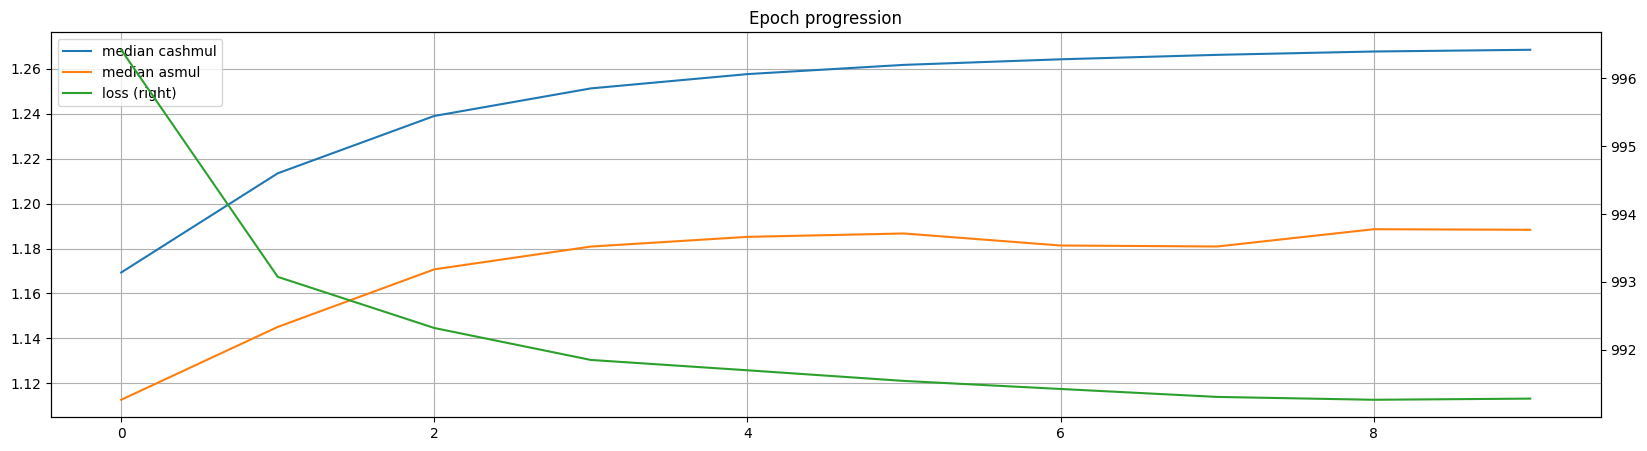

Assets  Liabilities  NetCashOperating_ttm  price  \
cik        snapshot                                                          
0000001750 2012-01-01   1.821612     0.957664              0.083588  19.17   
           2012-02-01   1.821612     0.957664              0.083588  21.19   
           2012-03-01   1.821612     0.957664              0.083588  22.05   
           2012-04-01   2.220293     1.330213              0.066898  18.25   
           2012-05-01   2.220293     1.330213              0.066898  15.45   
...                          ...          ...                   ...    ...   
0001915657 2025-09-01  16.843000     7.561000              1.067000  50.88   
           2025-10-01  16.843000     7.561000              1.067000  52.34   
           2025-11-01  17.264000     7.834000              1.167000  51.60   
           2025-12-01  17.264000     7.834000              1.167000  52.91   
           2026-01-01  17.264000     7.834000              1.167000  46.08   

                          asmul   cashmul      model  
cik        snapshot                                   
0000001750 2012-01-01  0.999809 -1.109959   0.770820  
           2012-02-01  0.999809 -0.973899   0.782193  
           2012-03-01  0.999809 -0.898071   0.788531  
           2012-04-01  0.999809 -0.832869   0.833938  
           2012-05-01  0.999809 -0.860210   0.832109  
...                         ...       ...        ...  
0001915657 2025-09-01  0.958395  1.555658  10.241135  
           2025-10-01  0.958395  1.547927  10.232886  
           2025-11-01  0.958395  1.434790  10.386132  
           2025-12-01  0.958395  1.468113  10.425020  
           2026-01-01  0.958395  1.475507  10.433649  

[438416 rows x 7 columns]

In [13]:
def model_train(model, num_epochs = 10000, epoch_batch = 1000):
    optimizer = torch.optim.Adagrad(params = model.parameters(), lr = 0.15)

    output_graphic = []

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        loss = model.get_total_loss()
        loss.backward()
        optimizer.step()
        if (epoch+1) % epoch_batch == 0:
            param_state = model.get_param_state()
            param_state['loss'] = loss.item()
            output_graphic.append(param_state)
            output_string = f"Epoch [{epoch+1}/{num_epochs}], "
            output_string += " ".join([f"{key}: {value:.8f};" for key,value in list(param_state.items())])
            print(output_string)

    output_graphic = pd.DataFrame(output_graphic)
    output_graphic.drop(columns='loss').plot(grid=True,figsize=(20,5),legend=True,title='Epoch progression')
    output_graphic['loss'].plot(secondary_y=True,legend=True,grid=False)
    plt.show()

model_train(pricing_model)
model_output = pricing_model.get_df()
model_output = model_output[~model_output['is_created']].drop(columns=['is_created'])
model_output

In [14]:
# We take the computed multipliers and put them into the original dataframe "snapshots"
mul_columns = ['asmul','cashmul']
result = pd.merge(snapshots,model_output.groupby(by=['snapshot','cik'])[mul_columns].mean(),left_index=True,right_index=True,how='left')
result['model'] = result['asmul']*result['Assets'] - result['Liabilities'] + result['cashmul']*result['NetCashOperating_ttm']
# Sample data: Amazon
result[result['ticker']=='AMZN'].tail(20)

,,,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model
snapshot,cik,date,,,,,,,,
2024-07-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,193.25,0.750492,1.255046,283.883910
2024-08-01,0001018724,2024-03-31,AMZN,530.969,314.308,159.120667,186.98,0.750492,1.505509,323.737865
2024-09-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,178.50,0.750492,1.529390,368.855393
2024-10-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.33,0.750492,1.562925,374.794023
2024-11-01,0001018724,2024-06-30,AMZN,554.818,318.371,177.090000,186.40,0.750492,1.485194,361.028806
2024-12-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,207.89,0.750492,1.747111,452.122924
2025-01-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,219.39,0.750492,1.485307,401.347695
2025-02-01,0001018724,2024-09-30,AMZN,584.626,325.475,193.943333,237.68,0.750492,1.564752,416.755570
2025-03-01,0001018724,2024-12-31,AMZN,624.894,338.924,197.114333,212.28,0.750492,1.483025,422.379777


Let's examine the achieved correlations using a histogram:

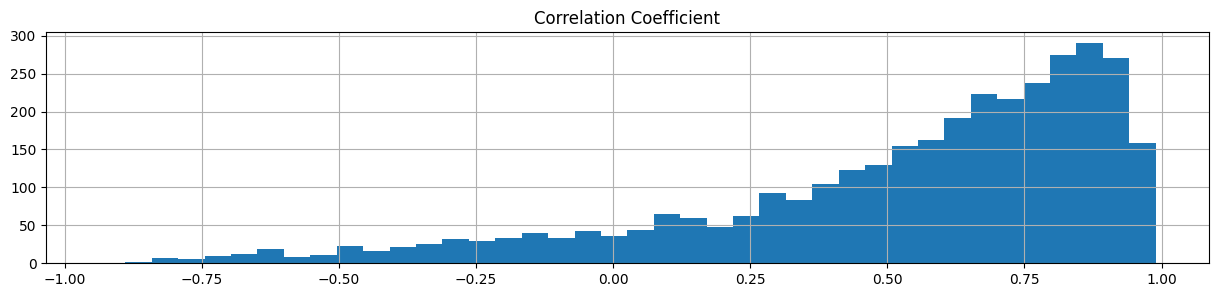

In [15]:
model_corr = result.dropna().groupby(by='cik')[[ml_label,'model']].corr().reset_index()
model_corr = model_corr[model_corr[model_corr.columns[1]]==ml_label][['cik','model']]
model_corr = model_corr.rename(columns={'model':'Correlation Coefficient'}).set_index('cik')
model_corr.hist(figsize=(15,3),bins=40)
plt.show()

It is interesting to see the development of the two multipliers over time. The cash multiplier is the same for all ciks on a given snapshot date and can probably serve as some form of valuation metric for the whole market.

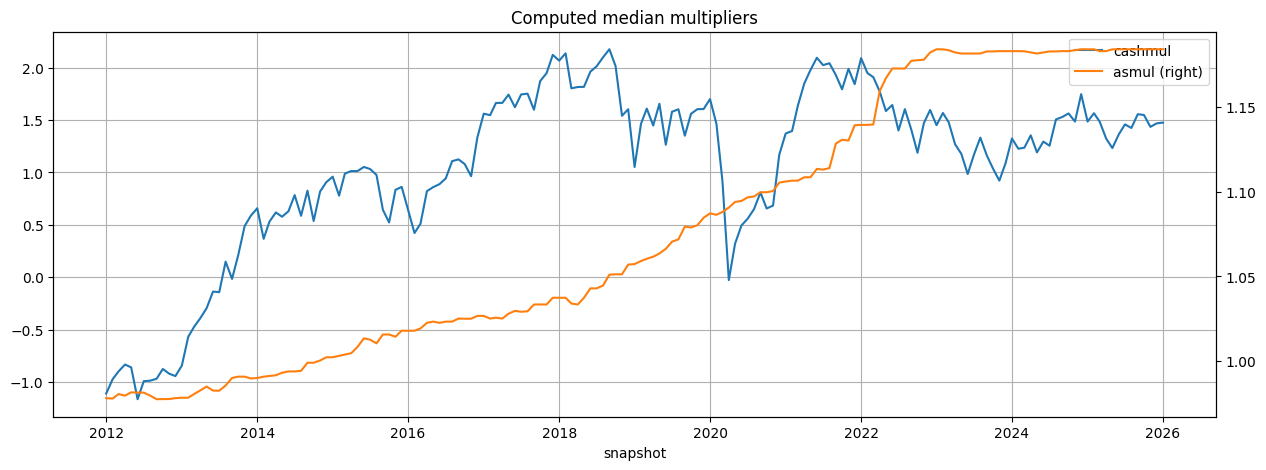

Median asset_multiplier per cik: 1.1884078979492188
Median asset_multiplier per snapshot: 1.0573022365570068


In [16]:
mul_graph = result.groupby(by='snapshot')[mul_columns].median()
mul_graph['cashmul'].plot(title='Computed median multipliers',figsize=(15,5),grid=True,legend=True)
mul_graph['asmul'].plot(secondary_y=True,legend=True,grid=False)
plt.show()
print("Median asset_multiplier per cik:",result['asmul'].groupby(by=['cik']).median().median())
print("Median asset_multiplier per snapshot:",result['asmul'].groupby(by=['snapshot']).median().median())

We can now output the results for later use in other models/notebooks/datasets

In [17]:
result.to_csv('/kaggle/working/pricing_model.csv.gz')

Finally, we apply the model to individual companies. I have tried to make the selection of sample tickers as varied as possible in terms of company kinds and sizes. Using the computed model values we can arrive at a fair price for each snapshot, that can be used to make some estimates if and how much the stock price corresponds to the underlying financials.

In other words, we may be able to determine if a stock is relatively over-or-undervalued, compared to its historic fundamentals.

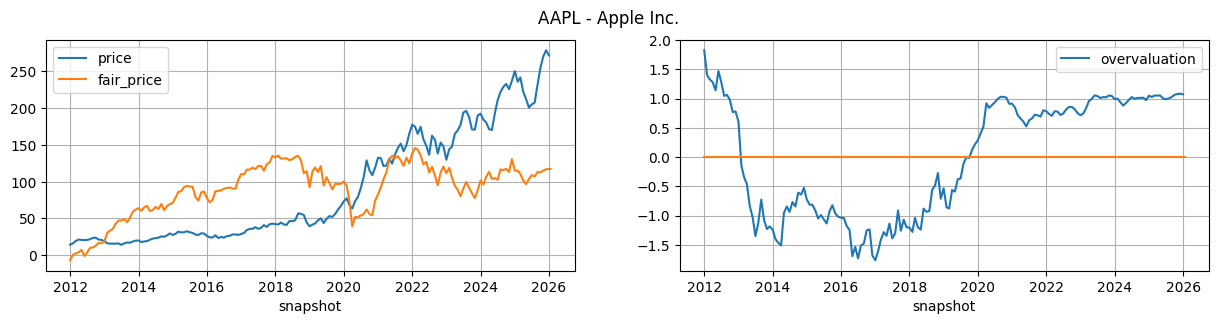

AAPL fair_price = 0.5085 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -34.4754


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000320193,2025-06-28,AAPL,331.495,265.665,108.565,1.167974,1.547927,289.563131,112.774250
2025-11-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,1.167974,1.434790,294.029278,115.045391
2025-12-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,1.167974,1.468113,297.744172,116.934501
2026-01-01,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,1.167974,1.475507,298.568478,117.353680
2026-01-17,0000320193,2025-09-27,AAPL,359.241,285.508,111.482,1.167974,1.475507,298.568478,117.353680


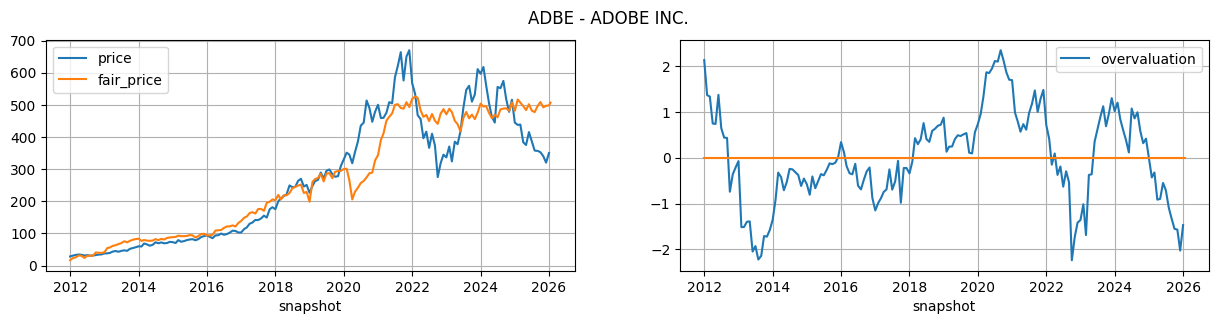

ADBE fair_price = 14.8161 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -107.8114


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.510378,1.547927,41.602725,508.578277
2025-11-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.510378,1.434790,40.494887,492.164441
2025-12-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.510378,1.468113,40.821184,496.998886
2026-01-01,0000796343,2025-08-29,ADBE,28.754,16.984,9.792,1.510378,1.475507,40.893586,498.071612
2026-01-17,0000796343,2025-11-28,ADBE,29.496,17.873,10.031,1.510378,1.475507,41.477933,506.729348


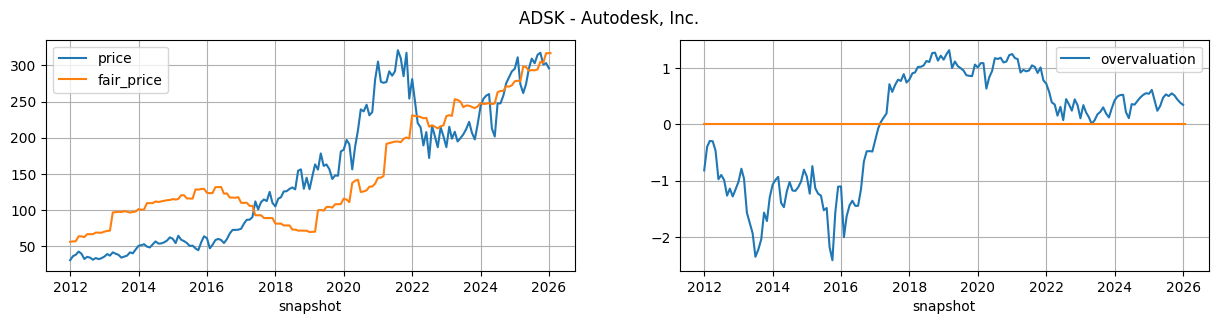

ADSK fair_price = 6.0459 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -36.2818


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,5.676881,1.547927,56.466978,305.114475
2025-11-01,0000769397,2025-07-31,ADSK,10.856,8.141,1.925,5.676881,1.434790,56.249189,303.797734
2025-12-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,5.676881,1.468113,58.428495,316.973698
2026-01-01,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,5.676881,1.475507,58.444429,317.070036
2026-01-17,0000769397,2025-10-31,ADSK,11.198,8.305,2.155,5.676881,1.475507,58.444429,317.070036


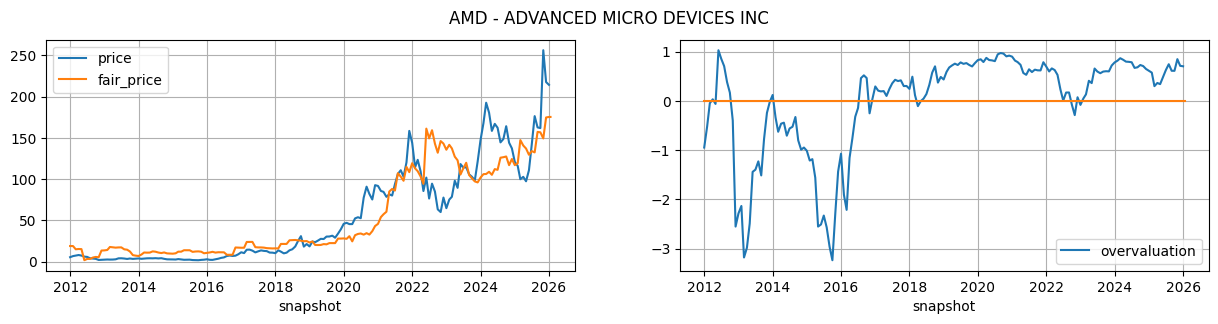

AMD fair_price = 13.4118 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 50.9448


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.207003,1.547927,7.882179,156.658952
2025-11-01,0000002488,2025-06-28,AMD,74.820,15.155,4.877,0.207003,1.434790,7.330410,149.258729
2025-12-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.207003,1.468113,9.223308,174.645897
2026-01-01,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.207003,1.475507,9.270689,175.281365
2026-01-17,0000002488,2025-09-27,AMD,76.891,16.101,6.408,0.207003,1.475507,9.270689,175.281365


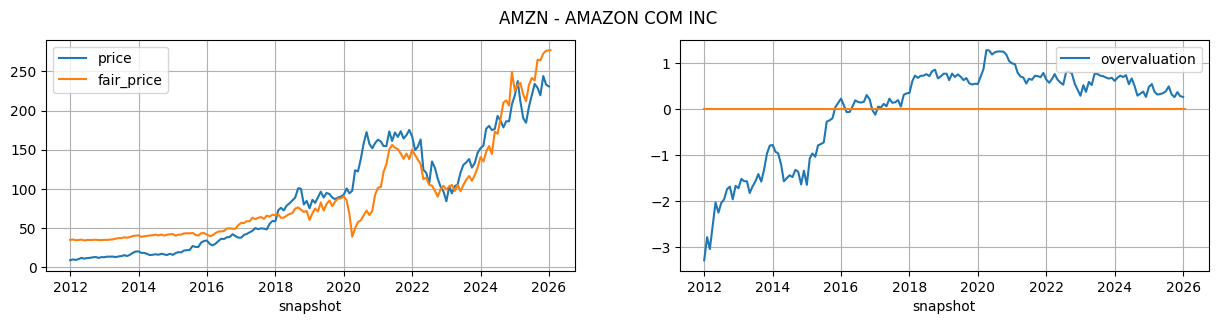

AMZN fair_price = 0.4702 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 36.7626


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001018724,2025-06-30,AMZN,682.170,348.395,206.735833,0.750492,1.547927,483.580444,264.148795
2025-11-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.750492,1.434790,502.371949,272.984818
2025-12-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.750492,1.468113,509.672983,276.417864
2026-01-01,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.750492,1.475507,511.293026,277.179630
2026-01-17,0001018724,2025-09-30,AMZN,727.921,358.290,219.100167,0.750492,1.475507,511.293026,277.179630


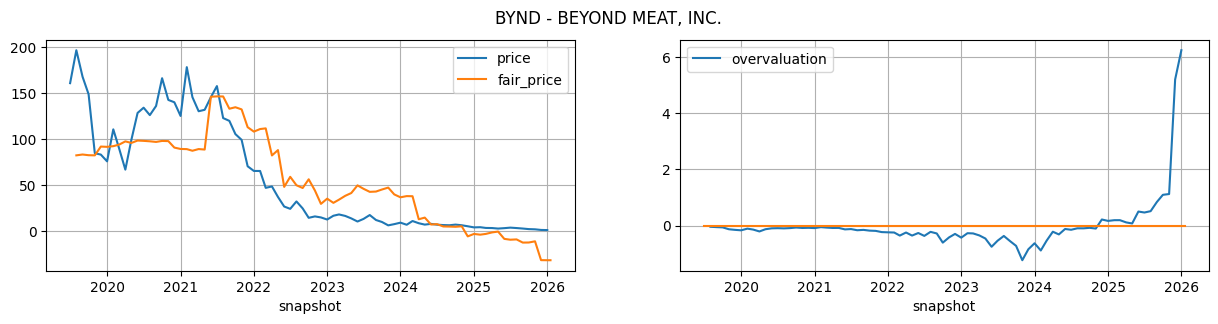

BYND fair_price = 103.0042 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 25.578


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.688655,1.547927,-0.371472,-12.685235
2025-11-01,0001655210,2025-06-28,BYND,0.691741,1.368764,-0.110354,1.688655,1.434790,-0.358987,-11.399214
2025-12-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688655,1.468113,-0.557683,-31.865678
2026-01-01,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688655,1.475507,-0.558622,-31.962472
2026-01-17,0001655210,2025-09-27,BYND,0.599669,1.383734,-0.127090,1.688655,1.475507,-0.558622,-31.962472


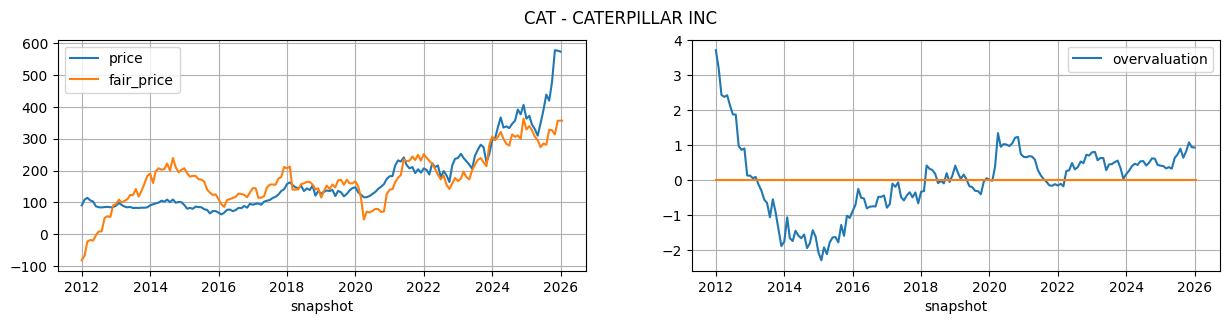

CAT fair_price = 10.4421 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -452.8307


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.42492,1.547927,74.648493,326.654978
2025-11-01,0000018230,2025-06-30,CAT,90.325,71.662,11.373,1.42492,1.434790,73.361784,313.219062
2025-12-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.42492,1.468113,77.426861,355.666934
2026-01-01,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.42492,1.475507,77.512196,356.558009
2026-01-17,0000018230,2025-09-30,CAT,93.722,73.063,11.541,1.42492,1.475507,77.512196,356.558009


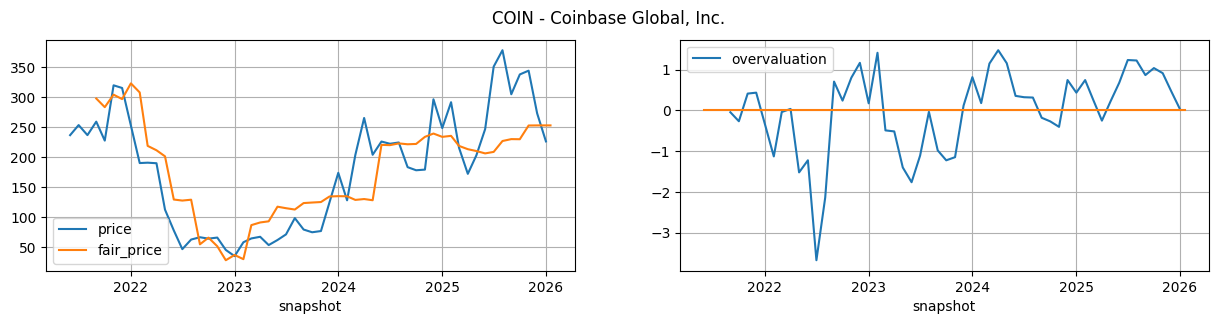

COIN fair_price = 13.269 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 27.3832


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001679788,2025-06-30,COIN,23.476038,11.381149,1.806909,1.015365,1.547927,15.252554,229.769585
2025-11-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015365,1.434790,16.972453,252.590964
2025-12-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015365,1.468113,16.983311,252.735042
2026-01-01,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015365,1.475507,16.985721,252.767012
2026-01-17,0001679788,2025-09-30,COIN,31.351367,15.328143,0.325850,1.015365,1.475507,16.985721,252.767012


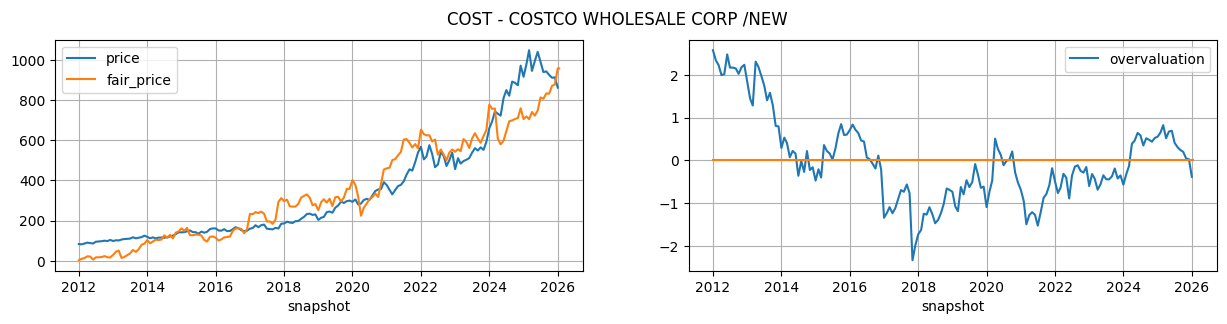

COST fair_price = 16.429 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -256.7042


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000909832,2025-05-11,COST,75.482,48.357,12.426,1.26381,1.547927,66.272443,832.084493
2025-11-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.26381,1.434790,68.636406,870.921995
2025-12-01,0000909832,2025-08-31,COST,77.099,47.935,13.335,1.26381,1.468113,69.080766,878.222372
2026-01-01,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.26381,1.475507,73.926732,957.836659
2026-01-17,0000909832,2025-11-23,COST,82.790,52.487,14.763,1.26381,1.475507,73.926732,957.836659


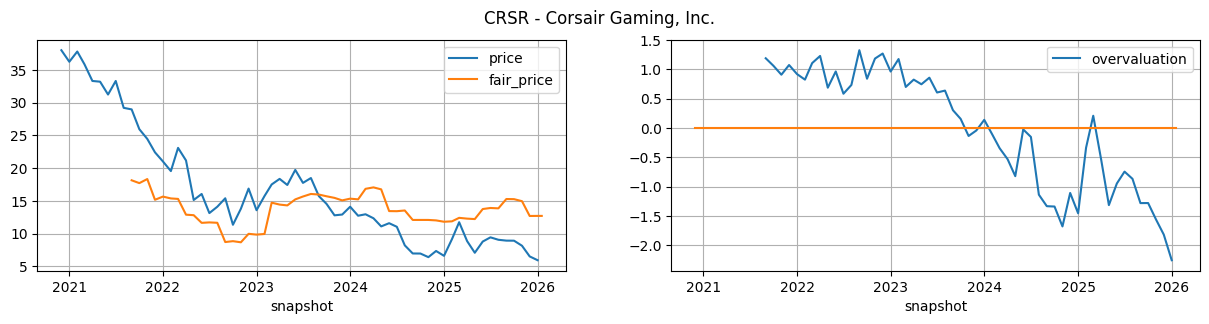

CRSR fair_price = 20.8834 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -20.7934


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.75436,1.547927,1.726244,15.256472
2025-11-01,0001743759,2025-06-30,CRSR,1.221880,0.617983,0.129599,1.75436,1.434790,1.711582,14.950269
2025-12-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.75436,1.468113,1.603437,12.691849
2026-01-01,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.75436,1.475507,1.603937,12.702273
2026-01-17,0001743759,2025-09-30,CRSR,1.198499,0.598269,0.067507,1.75436,1.475507,1.603937,12.702273


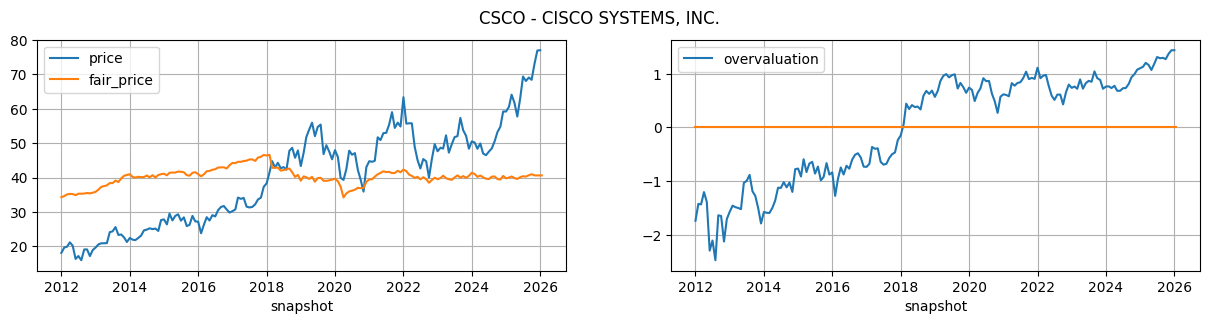

CSCO fair_price = 0.2123 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 27.9194


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.939741,1.547927,61.443547,40.961861
2025-11-01,0000858877,2025-07-26,CSCO,122.291,75.448,14.193,0.939741,1.434790,59.837792,40.621013
2025-12-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.939741,1.468113,59.753209,40.603058
2026-01-01,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.939741,1.475507,59.854833,40.624630
2026-01-17,0000858877,2025-10-25,CSCO,121.102,74.229,13.744,0.939741,1.475507,59.854833,40.624630


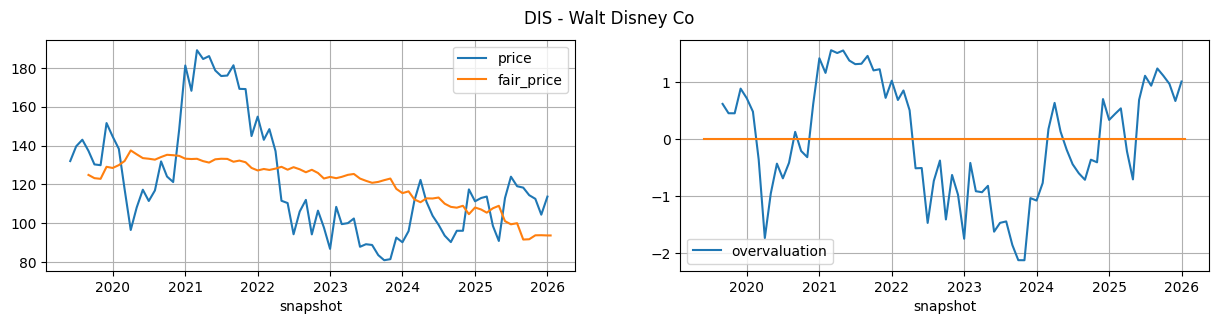

DIS fair_price = -0.9396 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 246.6793


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,1.132332,1.547927,164.798165,91.826726
2025-11-01,0001744489,2025-06-28,DIS,196.612,87.467,19.145,1.132332,1.434790,162.632154,93.862017
2025-12-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,1.132332,1.468113,162.580774,93.910297
2026-01-01,0001744489,2025-09-27,DIS,197.514,87.645,18.101,1.132332,1.475507,162.714614,93.784534
2026-01-17,0001744489,2025-09-27,DIS,197.514,87.645,18.101,1.132332,1.475507,162.714614,93.784534


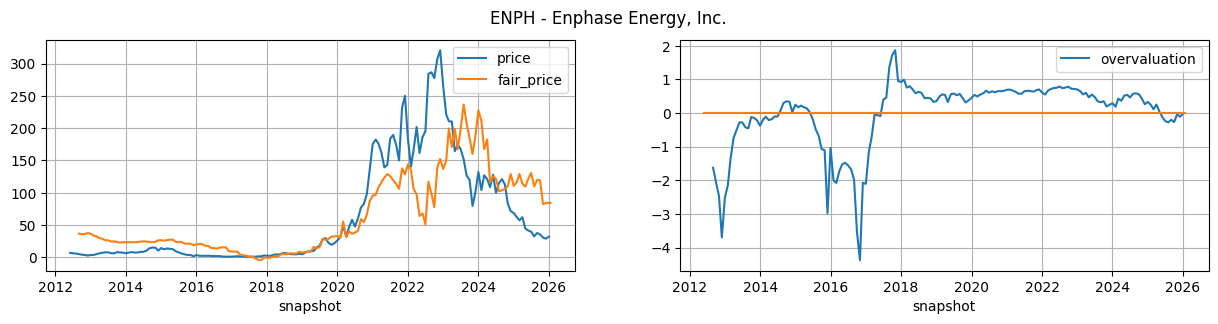

ENPH fair_price = 183.7492 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 23.0141


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001463101,2025-06-30,ENPH,3.178789,2.298152,0.412473,0.686918,1.547927,0.523893,119.279071
2025-11-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.686918,1.434790,0.323106,82.384555
2025-12-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.686918,1.468113,0.331645,83.953603
2026-01-01,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.686918,1.475507,0.333540,84.301762
2026-01-17,0001463101,2025-09-30,ENPH,3.320488,2.325466,0.256253,0.686918,1.475507,0.333540,84.301762


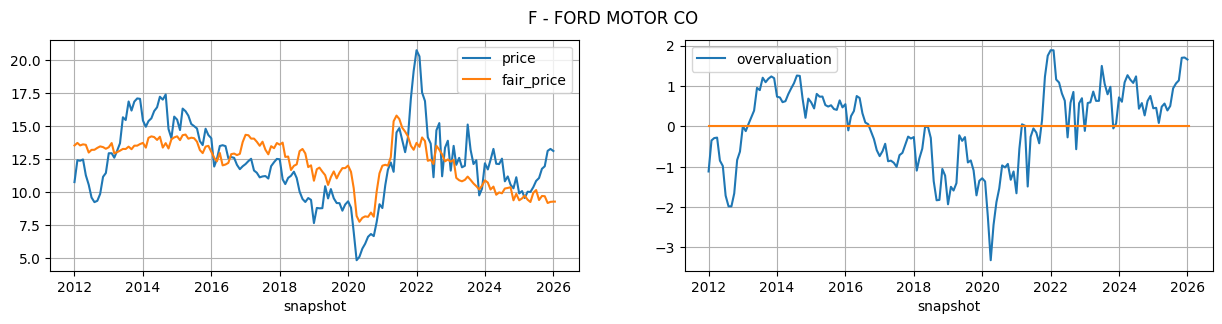

F fair_price = 0.1262 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 31.8605


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000037996,2025-06-30,F,292.725,247.668,18.526,0.14772,1.547927,-175.749836,9.688565
2025-11-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.14772,1.434790,-179.828810,9.173977
2025-12-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.14772,1.468113,-179.148158,9.259846
2026-01-01,0000037996,2025-09-30,F,300.990,253.598,20.426,0.14772,1.475507,-178.997127,9.278899
2026-01-17,0000037996,2025-09-30,F,300.990,253.598,20.426,0.14772,1.475507,-178.997127,9.278899


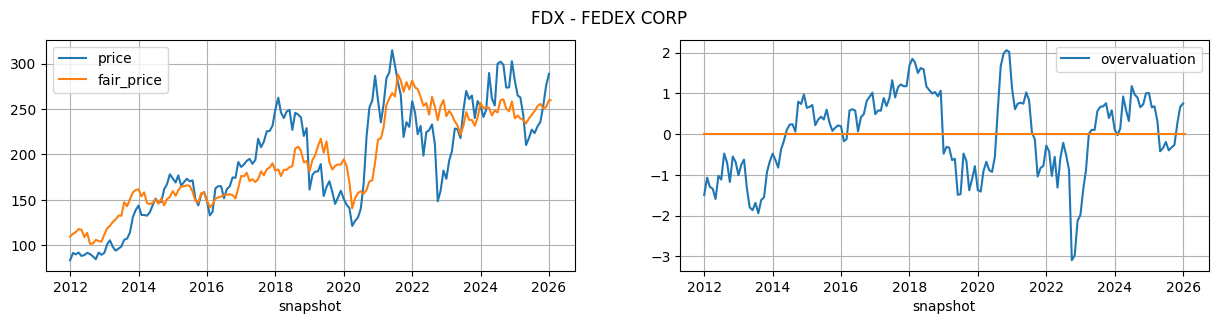

FDX fair_price = 5.7725 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 52.2738


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.952007,1.547927,35.237746,255.685326
2025-11-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.952007,1.434790,34.381863,250.744704
2025-12-01,0001048911,2025-08-31,FDX,88.416,60.645,7.565,0.952007,1.468113,34.633950,252.199889
2026-01-01,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.952007,1.475507,35.956168,259.832452
2026-01-17,0001048911,2025-11-30,FDX,89.181,61.041,8.198,0.952007,1.475507,35.956168,259.832452


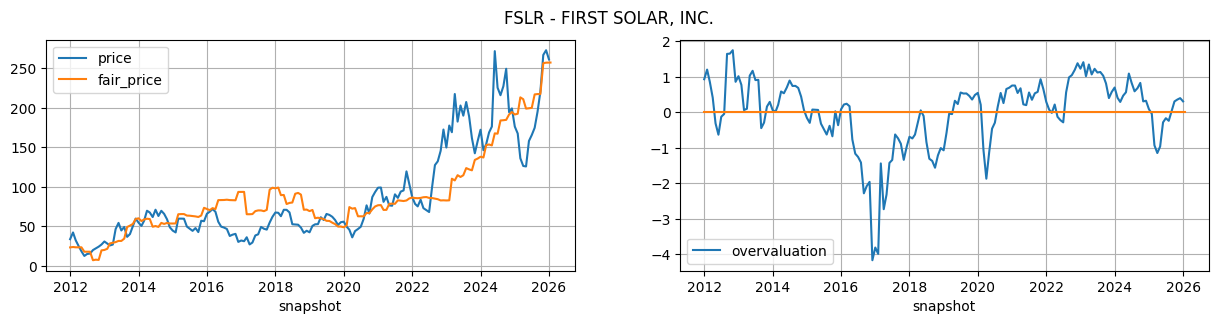

FSLR fair_price = 11.9961 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -126.6246


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001274494,2025-06-30,FSLR,12.858044,4.311914,0.298857,2.529858,1.547927,28.679716,217.420134
2025-11-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.529858,1.434790,31.939406,256.523697
2025-12-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.529858,1.468113,31.993595,257.173763
2026-01-01,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.529858,1.475507,32.005620,257.318008
2026-01-17,0001274494,2025-09-30,FSLR,13.459309,4.443997,1.626208,2.529858,1.475507,32.005620,257.318008


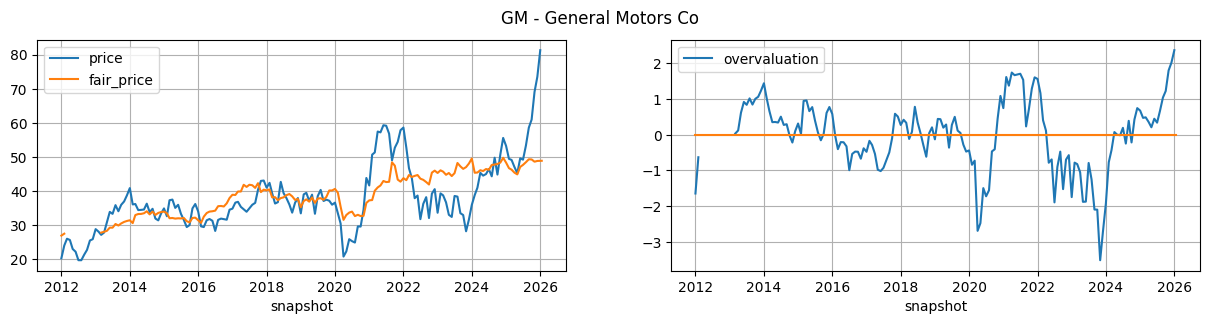

GM fair_price = 0.2734 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 17.4522


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001467858,2025-06-30,GM,289.384,223.021,23.970,1.044663,1.547927,116.391661,49.274208
2025-11-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.044663,1.434790,113.983673,48.615853
2025-12-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.044663,1.468113,114.790484,48.836439
2026-01-01,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.044663,1.475507,114.969510,48.885386
2026-01-17,0001467858,2025-09-30,GM,288.168,221.794,24.212,1.044663,1.475507,114.969510,48.885386


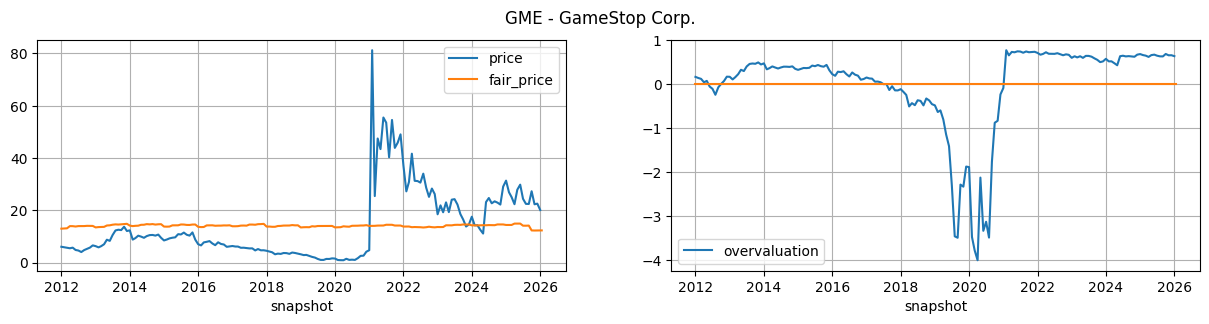

GME fair_price = 0.7164 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 15.4343


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000137,1.547927,-4.394271,12.286164
2025-11-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000137,1.434790,-4.450478,12.245897
2025-12-01,0001326380,2025-08-02,GME,10.3411,5.1647,0.4968,0.000137,1.468113,-4.433923,12.257757
2026-01-01,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000137,1.475507,-4.385294,12.292595
2026-01-17,0001326380,2025-11-01,GME,10.5507,5.2477,0.5835,0.000137,1.475507,-4.385294,12.292595


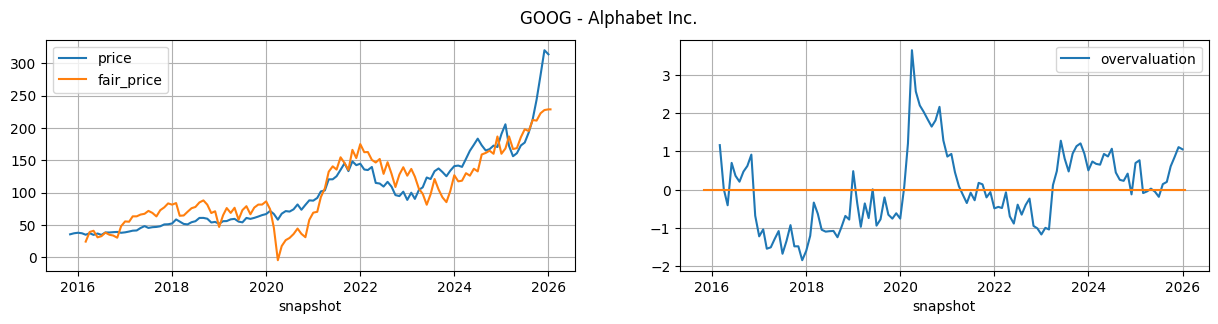

GOOG fair_price = 0.9713 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -23.676


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001652044,2025-06-30,GOOG,502.053,139.137,133.708,0.346761,1.547927,241.925577,211.294668
2025-11-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.346761,1.434790,253.686100,222.717100
2025-12-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.346761,1.468113,258.731973,227.617915
2026-01-01,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.346761,1.475507,259.851614,228.705368
2026-01-17,0001652044,2025-09-30,GOOG,536.469,149.602,151.424,0.346761,1.475507,259.851614,228.705368


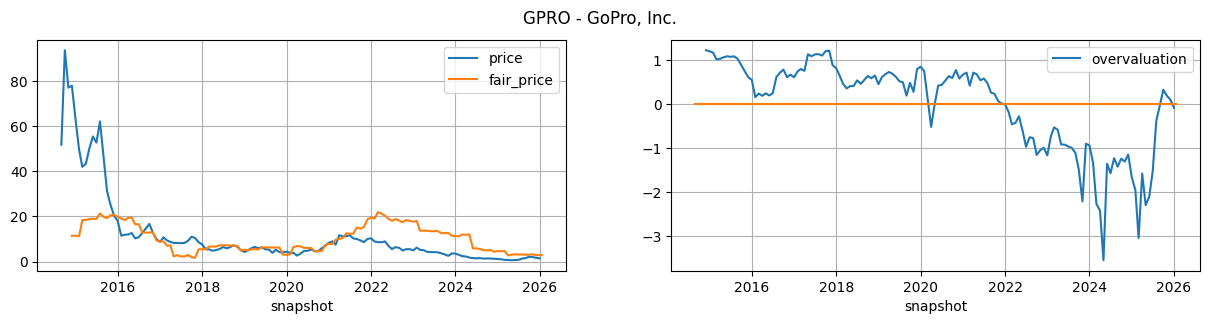

GPRO fair_price = 20.4189 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 5.0464


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.81745,1.547927,-0.099520,3.014300
2025-11-01,0001500435,2025-06-30,GPRO,0.438990,0.341075,-0.075777,0.81745,1.434790,-0.090947,3.189355
2025-12-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.81745,1.468113,-0.107928,2.842607
2026-01-01,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.81745,1.475507,-0.108382,2.833341
2026-01-17,0001500435,2025-09-30,GPRO,0.538608,0.458114,-0.061371,0.81745,1.475507,-0.108382,2.833341


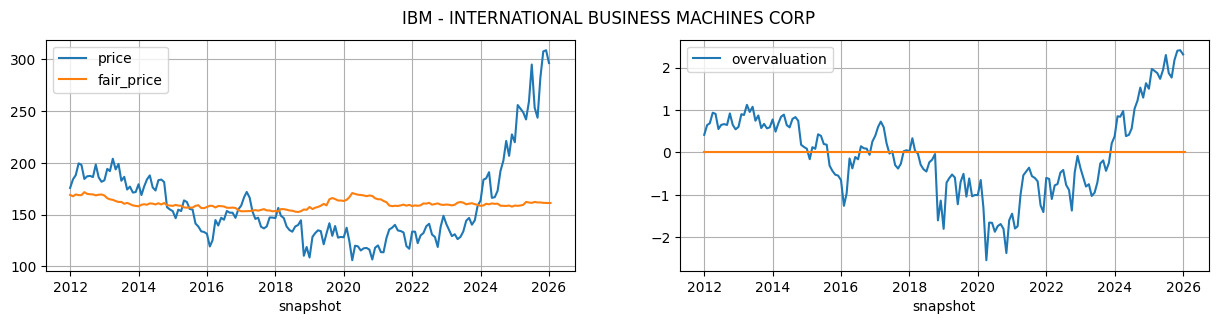

IBM fair_price = -0.2921 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 134.1564


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000051143,2025-06-30,IBM,148.585,121.076,13.282,0.039956,1.547927,-94.579602,161.782101
2025-11-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.039956,1.434790,-93.215716,161.383724
2025-12-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.039956,1.468113,-92.766424,161.252490
2026-01-01,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.039956,1.475507,-92.666730,161.223371
2026-01-17,0000051143,2025-09-30,IBM,146.312,118.407,13.483,0.039956,1.475507,-92.666730,161.223371


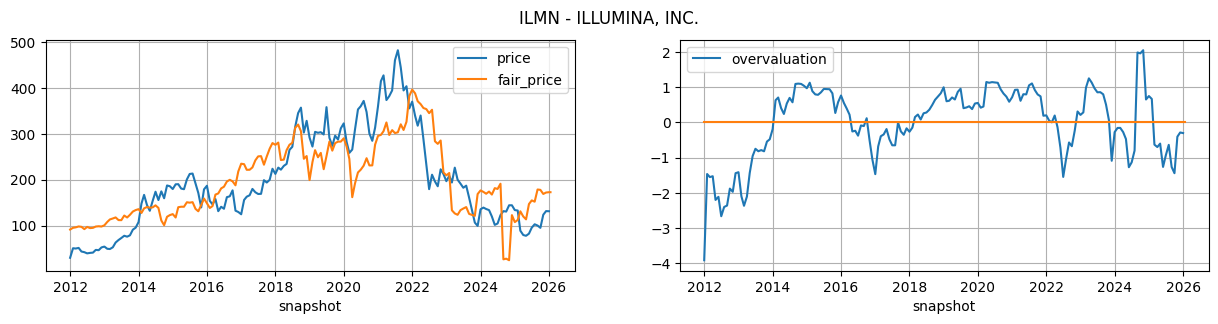

ILMN fair_price = 83.7471 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 142.2535


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001110803,2025-06-29,ILMN,6.087,3.829,1.154,0.405322,1.547927,0.424503,177.804395
2025-11-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.405322,1.434790,0.317508,168.843912
2025-12-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.405322,1.468113,0.354896,171.975065
2026-01-01,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.405322,1.475507,0.363193,172.669844
2026-01-17,0001110803,2025-09-28,ILMN,6.177,3.796,1.122,0.405322,1.475507,0.363193,172.669844


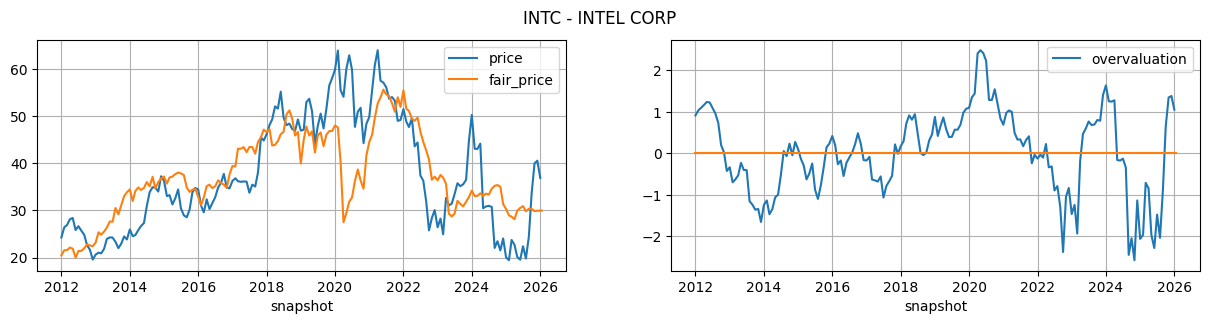

INTC fair_price = 0.4075 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 26.0208


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.465281,1.547927,10.545187,30.317789
2025-11-01,0000050863,2025-06-28,INTC,192.520,94.637,10.082,0.465281,1.434790,9.404539,29.852991
2025-12-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.465281,1.468113,9.606171,29.935153
2026-01-01,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.465281,1.475507,9.669568,29.960986
2026-01-17,0000050863,2025-09-27,INTC,204.514,98.138,8.574,0.465281,1.475507,9.669568,29.960986


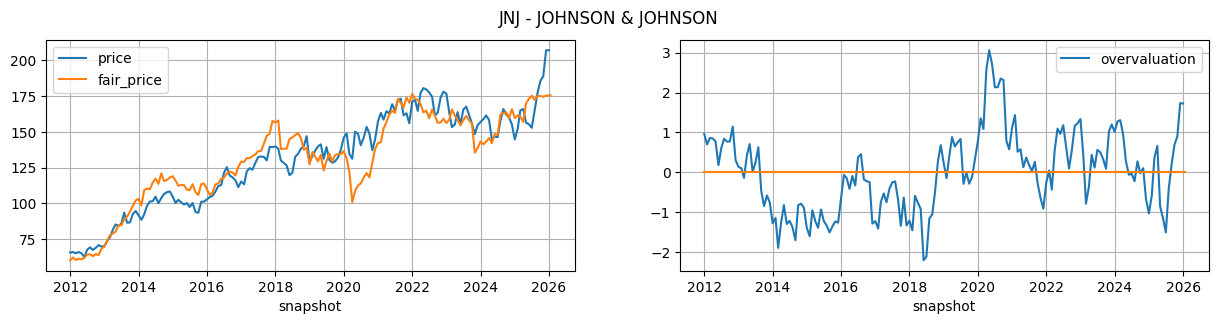

JNJ fair_price = 0.9506 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -50.2232


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000200406,2025-06-29,JNJ,193.389,114.916,23.028,1.63456,1.547927,236.835657,174.909800
2025-11-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.63456,1.434790,236.358045,174.455788
2025-12-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.63456,1.468113,237.164591,175.222480
2026-01-01,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.63456,1.475507,237.343557,175.392603
2026-01-17,0000200406,2025-09-28,JNJ,192.816,113.539,24.204,1.63456,1.475507,237.343557,175.392603


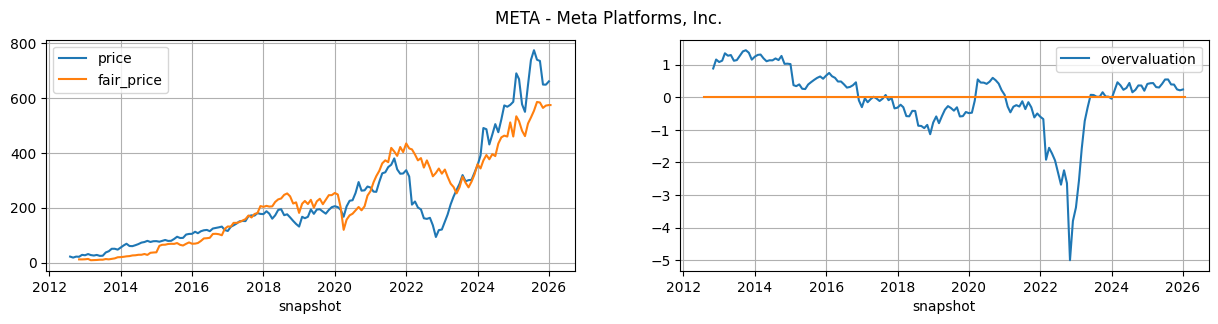

META fair_price = 2.3797 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -4.0759


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001326801,2025-06-30,META,294.744,99.674,102.299,0.637974,1.547927,246.716326,583.037284
2025-11-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.637974,1.434790,238.412590,563.276804
2025-12-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.637974,1.468113,241.997258,571.807272
2026-01-01,0001326801,2025-09-30,META,303.844,109.778,107.574,0.637974,1.475507,242.792668,573.700118
2026-01-17,0001326801,2025-09-30,META,303.844,109.778,107.574,0.637974,1.475507,242.792668,573.700118


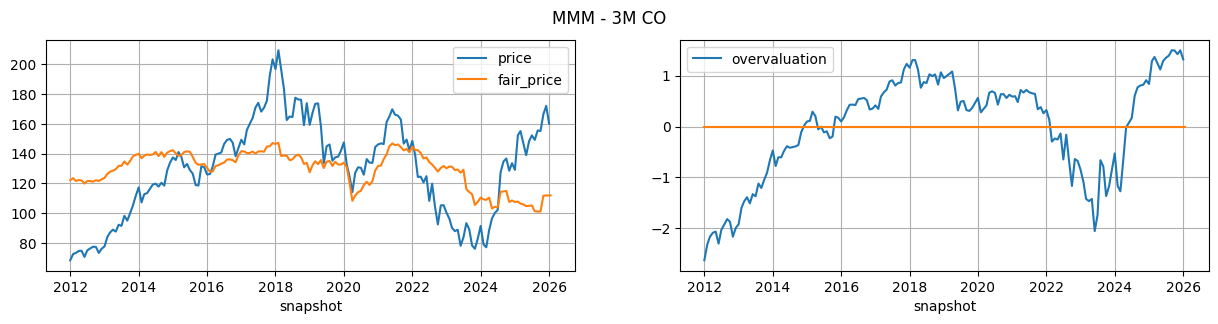

MMM fair_price = 1.8635 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 130.2756


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000066740,2025-06-30,MMM,37.989,33.699,-1.002,0.514881,1.547927,-15.690213,101.037392
2025-11-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.514881,1.434790,-9.972013,111.693078
2025-12-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.514881,1.468113,-9.887340,111.850864
2026-01-01,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.514881,1.475507,-9.868552,111.885875
2026-01-17,0000066740,2025-09-30,MMM,37.611,32.983,2.541,0.514881,1.475507,-9.868552,111.885875


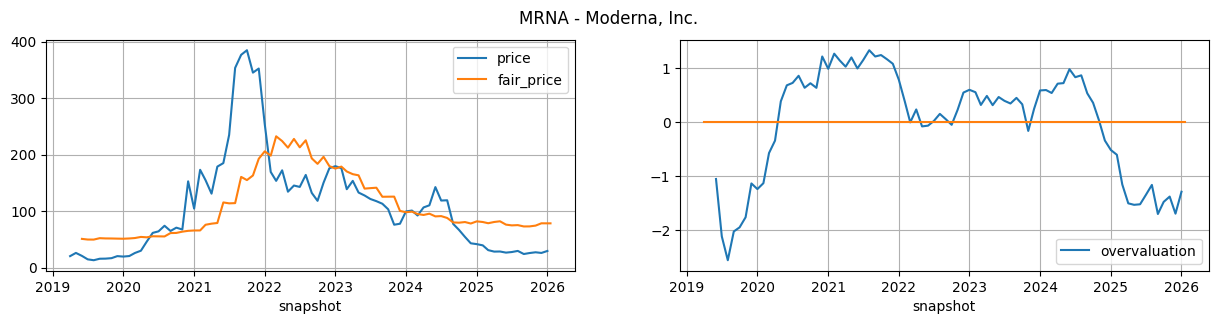

MRNA fair_price = 4.559 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 48.9101


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,1.004615,1.547927,5.279669,72.980302
2025-11-01,0001682852,2025-06-30,MRNA,12.010,2.611,-2.697,1.004615,1.434790,5.584800,74.371405
2025-12-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,1.004615,1.468113,6.482078,78.462131
2026-01-01,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,1.004615,1.475507,6.467453,78.395453
2026-01-17,0001682852,2025-09-30,MRNA,12.135,2.805,-1.978,1.004615,1.475507,6.467453,78.395453


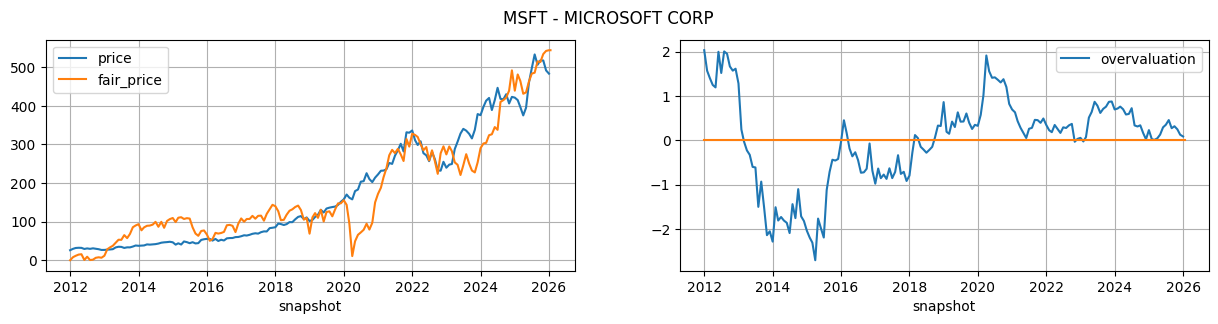

MSFT fair_price = 1.6459 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 25.679


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000789019,2025-06-30,MSFT,619.003,275.524,136.162,0.583779,1.547927,296.605609,513.849940
2025-11-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.583779,1.434790,309.183235,534.550937
2025-12-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.583779,1.468113,314.082988,542.615238
2026-01-01,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.583779,1.475507,315.170206,544.404645
2026-01-17,0000789019,2025-09-30,MSFT,636.351,273.275,147.039,0.583779,1.475507,315.170206,544.404645


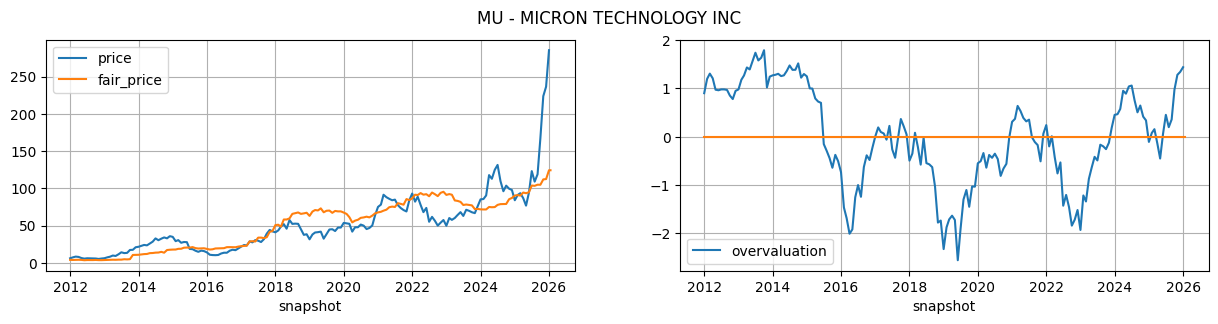

MU fair_price = 0.7574 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -11.512


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000723125,2025-05-29,MU,78.397,27.649,15.200,2.013363,1.547927,153.721084,104.917458
2025-11-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,2.013363,1.434790,163.214095,112.107532
2025-12-01,0000723125,2025-08-28,MU,82.798,28.633,17.525,2.013363,1.468113,163.798078,112.549844
2026-01-01,0000723125,2025-11-27,MU,85.971,27.165,22.692,2.013363,1.475507,179.408003,124.372911
2026-01-17,0000723125,2025-11-27,MU,85.971,27.165,22.692,2.013363,1.475507,179.408003,124.372911


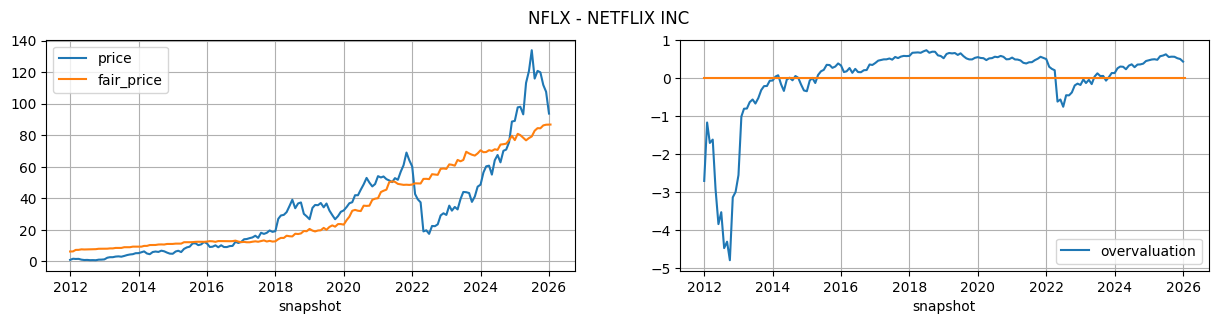

NFLX fair_price = 1.3777 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 5.3672


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001065280,2025-06-30,NFLX,53.099664,28.147765,9.070452,1.346143,1.547927,57.372375,84.410691
2025-11-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.346143,1.434790,58.706777,86.249133
2025-12-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.346143,1.468113,59.025827,86.688697
2026-01-01,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.346143,1.475507,59.096622,86.786233
2026-01-17,0001065280,2025-09-30,NFLX,54.934835,28.980800,9.574525,1.346143,1.475507,59.096622,86.786233


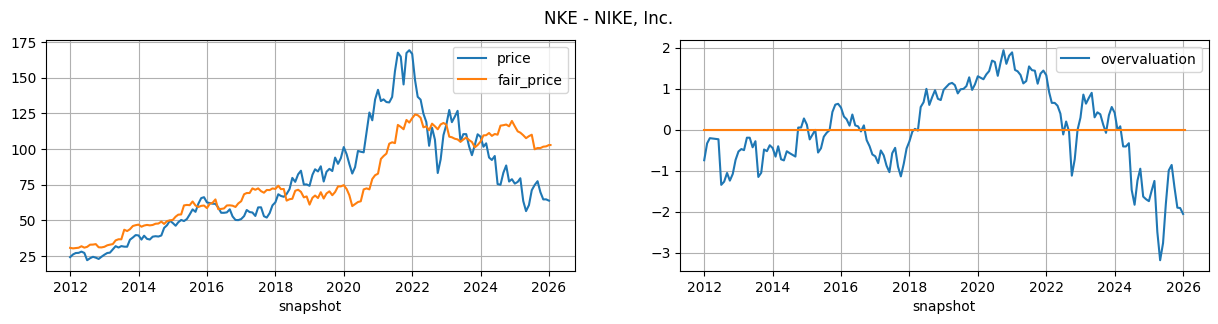

NKE fair_price = 1.83 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -18.0746


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000320187,2025-05-31,NKE,36.579,23.366,3.698,2.255064,1.547927,64.846221,100.595388
2025-11-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.255064,1.434790,65.383629,101.578858
2025-12-01,0000320187,2025-08-31,NKE,37.334,23.866,3.526,2.255064,1.468113,65.501126,101.793878
2026-01-01,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.255064,1.475507,66.019253,102.742063
2026-01-17,0000320187,2025-11-30,NKE,37.787,23.702,3.056,2.255064,1.475507,66.019253,102.742063


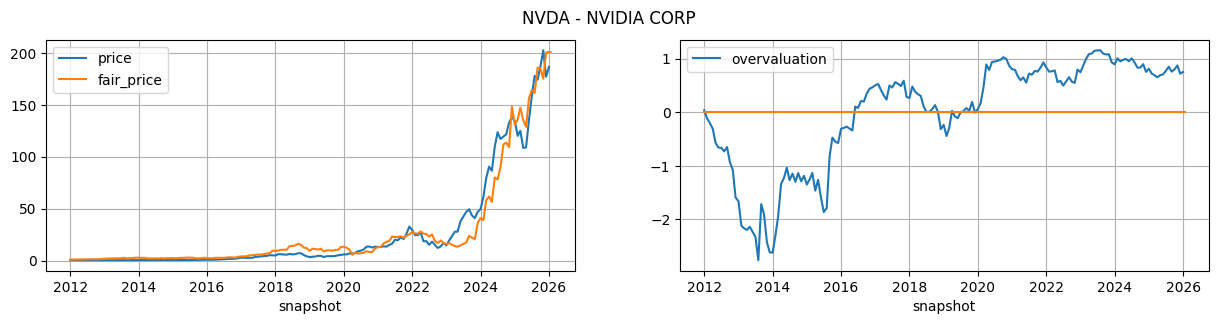

NVDA fair_price = 1.1496 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -0.1427


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.585749,1.547927,161.073903,185.023187
2025-11-01,0001045810,2025-07-27,NVDA,140.740,40.609,77.035,0.585749,1.434790,152.358384,175.004078
2025-12-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.585749,1.468113,174.228098,200.144872
2026-01-01,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.585749,1.475507,174.842982,200.851725
2026-01-17,0001045810,2025-10-26,NVDA,161.148,42.251,83.159,0.585749,1.475507,174.842982,200.851725


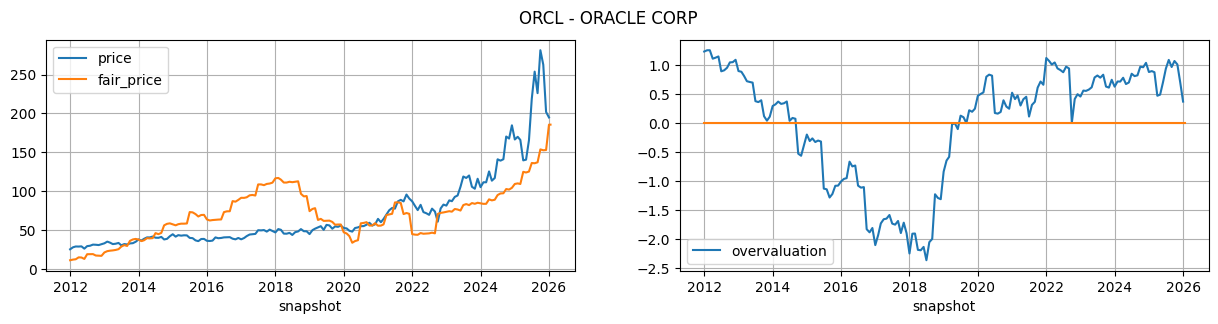

ORCL fair_price = 0.449 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -87.9643


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.666628,1.547927,538.677355,153.898154
2025-11-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.666628,1.434790,536.241060,152.804274
2025-12-01,0001341439,2025-08-31,ORCL,180.449,156.295,21.534,3.666628,1.468113,536.958634,153.126460
2026-01-01,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.666628,1.475507,609.464903,185.681281
2026-01-17,0001341439,2025-11-30,ORCL,204.984,175.033,22.296,3.666628,1.475507,609.464903,185.681281


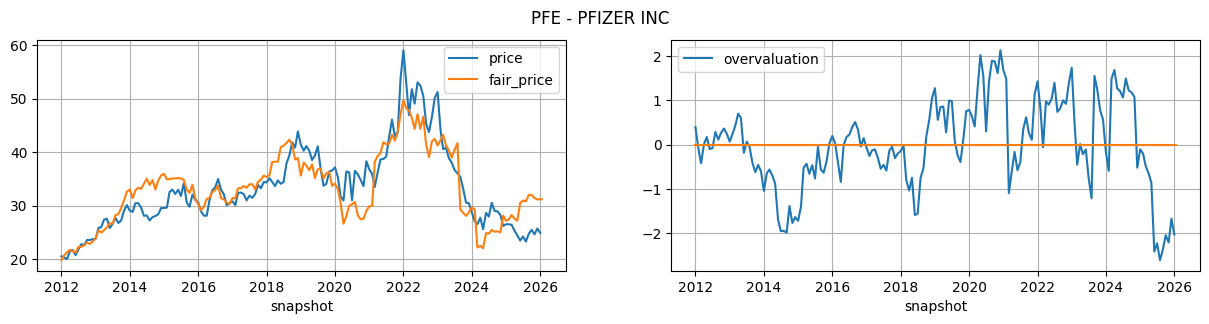

PFE fair_price = 0.3275 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 53.194


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.141294,1.547927,-64.770107,31.982532
2025-11-01,0000078003,2025-06-29,PFE,206.095,117.40,15.188,0.141294,1.434790,-66.488434,31.419799
2025-12-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.141294,1.468113,-67.239063,31.173976
2026-01-01,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.141294,1.475507,-67.142370,31.205642
2026-01-17,0000078003,2025-09-28,PFE,208.731,115.93,13.077,0.141294,1.475507,-67.142370,31.205642


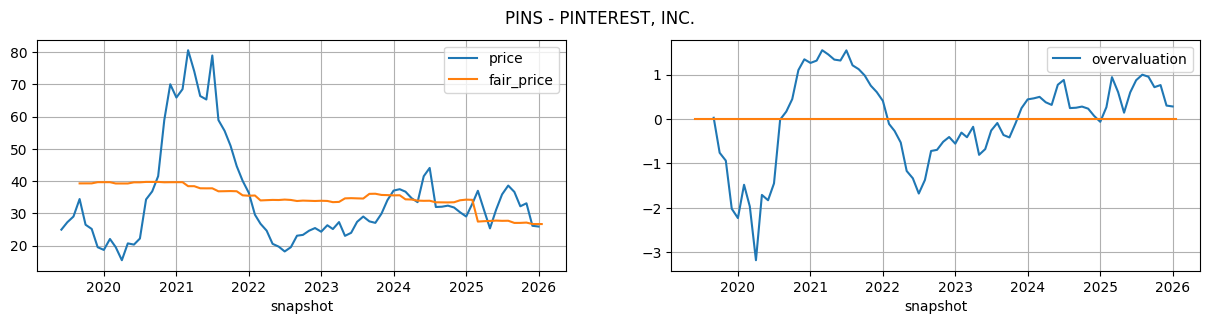

PINS fair_price = -0.7999 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 47.7522


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,4.599096,1.547927,25.919398,27.019071
2025-11-01,0001506293,2025-06-30,PINS,5.402987,0.591034,1.073421,4.599096,1.434790,25.797955,27.116215
2025-12-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,4.599096,1.468113,26.359450,26.667070
2026-01-01,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,4.599096,1.475507,26.367931,26.660286
2026-01-17,0001506293,2025-09-30,PINS,5.515410,0.690442,1.147046,4.599096,1.475507,26.367931,26.660286


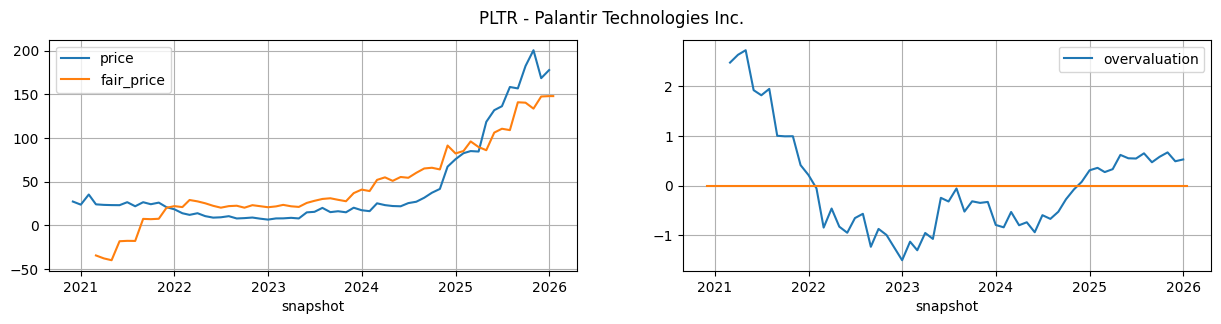

PLTR fair_price = 34.7618 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -5.183


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.400034,1.547927,4.187054,140.366358
2025-11-01,0001321655,2025-06-30,PLTR,7.365688,1.436787,1.729613,0.400034,1.434790,3.991370,133.564057
2025-12-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.400034,1.468113,4.390660,147.444053
2026-01-01,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.400034,1.475507,4.404098,147.911209
2026-01-17,0001321655,2025-09-30,PLTR,8.113960,1.523503,1.817505,0.400034,1.475507,4.404098,147.911209


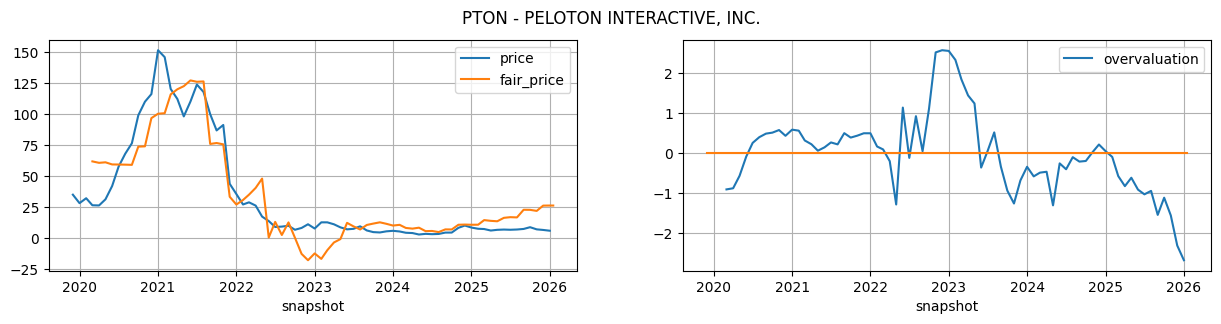

PTON fair_price = 22.7718 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -2.7532


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.48446,1.547927,1.131282,23.008094
2025-11-01,0001639825,2025-06-30,PTON,2.1253,2.5391,0.3330,1.48446,1.434790,1.093607,22.150174
2025-12-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.48446,1.468113,1.280413,26.404088
2026-01-01,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.48446,1.475507,1.283315,26.470159
2026-01-17,0001639825,2025-09-30,PTON,2.1701,2.5171,0.3924,1.48446,1.475507,1.283315,26.470159


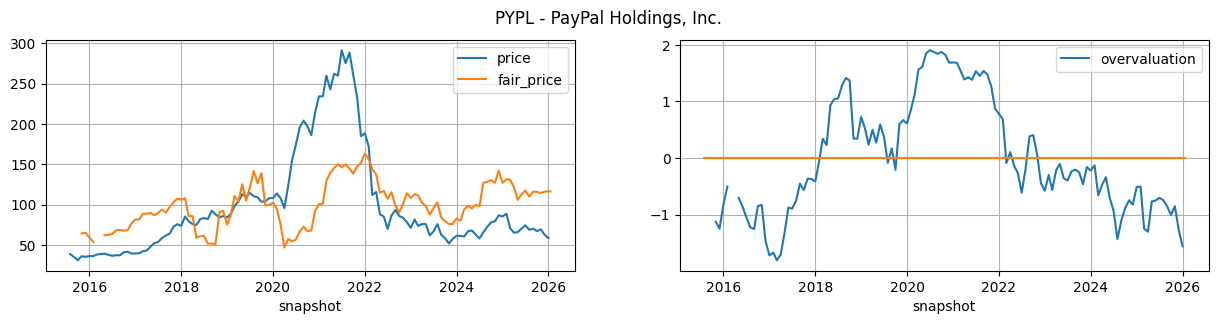

PYPL fair_price = 7.5475 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -29.669


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001633917,2025-06-30,PYPL,79.777,59.576,6.066,0.870562,1.547927,19.264581,115.730030
2025-11-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.870562,1.434790,19.088709,114.402640
2025-12-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.870562,1.468113,19.302841,116.018800
2026-01-01,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.870562,1.475507,19.350355,116.377413
2026-01-17,0001633917,2025-09-30,PYPL,79.801,59.603,6.426,0.870562,1.475507,19.350355,116.377413


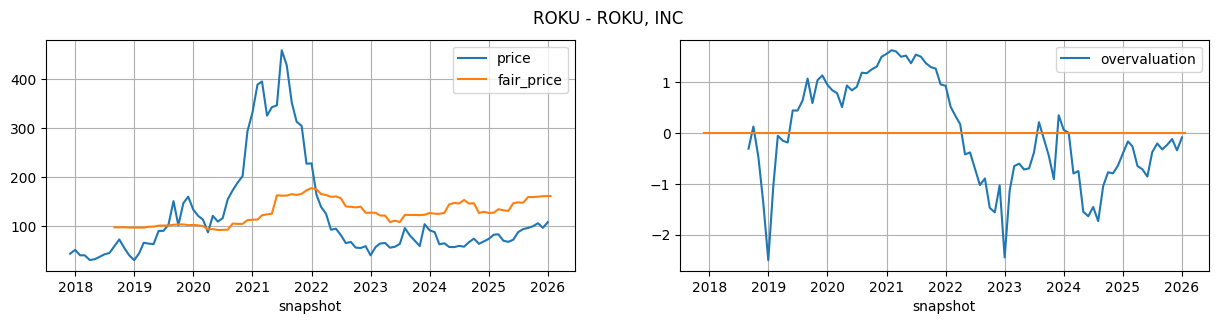

ROKU fair_price = 61.913 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 97.4046


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001428439,2025-06-30,ROKU,4.281955,1.691403,0.396421,0.485785,1.547927,1.002337,159.462241
2025-11-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.485785,1.434790,1.017281,160.387513
2025-12-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.485785,1.468113,1.032455,161.326973
2026-01-01,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.485785,1.475507,1.035822,161.535432
2026-01-17,0001428439,2025-09-30,ROKU,4.397285,1.772199,0.455360,0.485785,1.475507,1.035822,161.535432


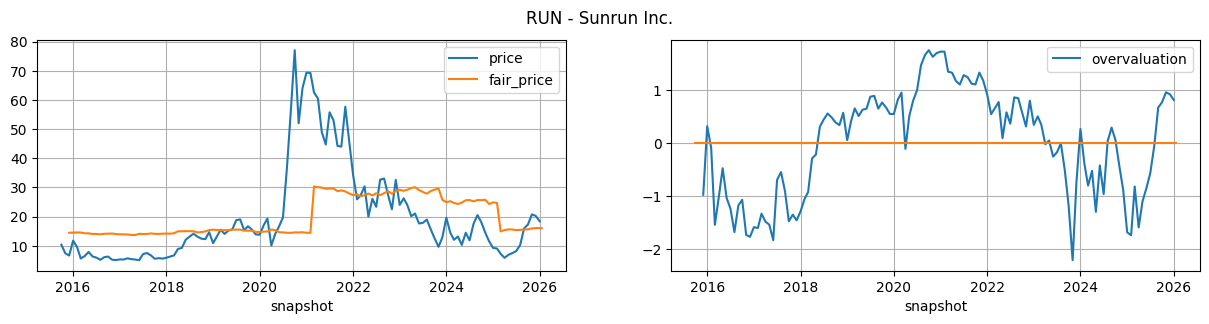

RUN fair_price = 3.5063 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 13.1041


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.955103,1.547927,0.717606,15.620228
2025-11-01,0001469367,2025-06-30,RUN,21.230135,18.303408,-0.811380,0.955103,1.434790,0.809404,15.942092
2025-12-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.955103,1.468113,0.845698,16.069352
2026-01-01,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.955103,1.475507,0.839955,16.049214
2026-01-17,0001469367,2025-09-30,RUN,22.225482,19.241580,-0.776747,0.955103,1.475507,0.839955,16.049214


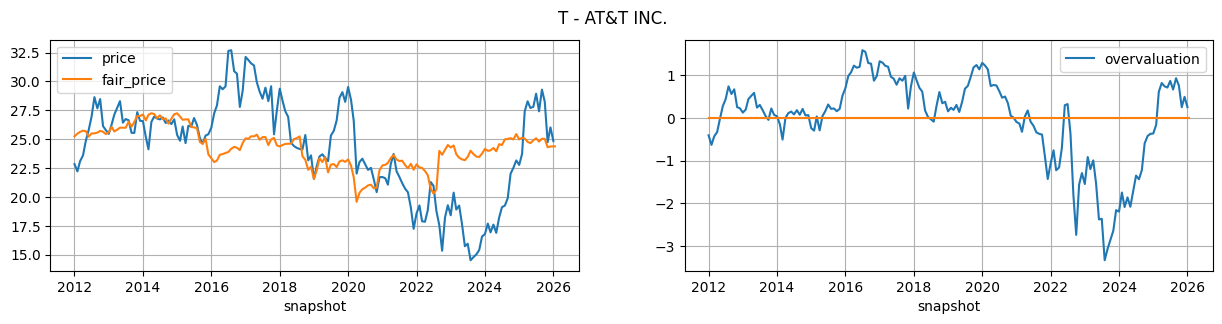

T fair_price = 0.0463 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 33.6186


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000732717,2025-06-30,T,405.491,284.097,40.943,0.086927,1.547927,-185.472252,25.022966
2025-11-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.086927,1.434790,-201.043999,24.301300
2025-12-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.086927,1.468113,-199.682429,24.364401
2026-01-01,0000732717,2025-09-30,T,423.213,296.458,40.860,0.086927,1.475507,-199.380307,24.378403
2026-01-17,0000732717,2025-09-30,T,423.213,296.458,40.860,0.086927,1.475507,-199.380307,24.378403


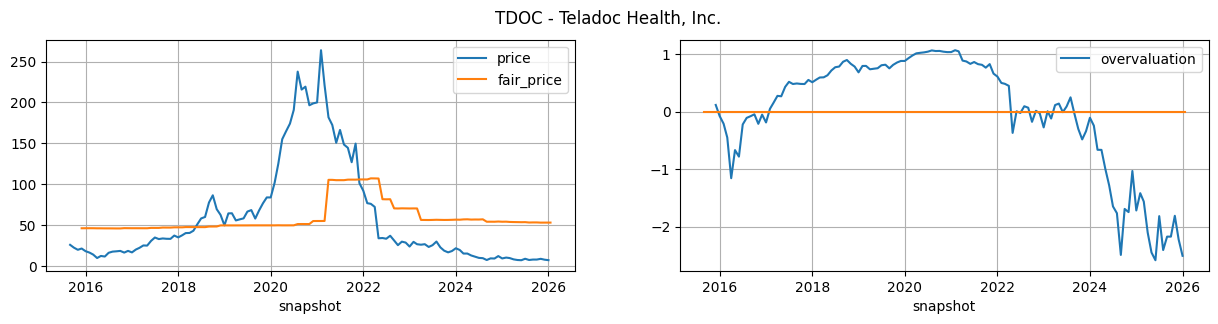

TDOC fair_price = 2.906 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 45.38


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001477449,2025-06-30,TDOC,2.894004,1.471865,0.303428,1.271335,1.547927,2.677067,53.159648
2025-11-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.271335,1.434790,2.592865,52.914956
2025-12-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.271335,1.468113,2.602612,52.943282
2026-01-01,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.271335,1.475507,2.604775,52.949568
2026-01-17,0001477449,2025-09-30,TDOC,2.878547,1.486432,0.292517,1.271335,1.475507,2.604775,52.949568


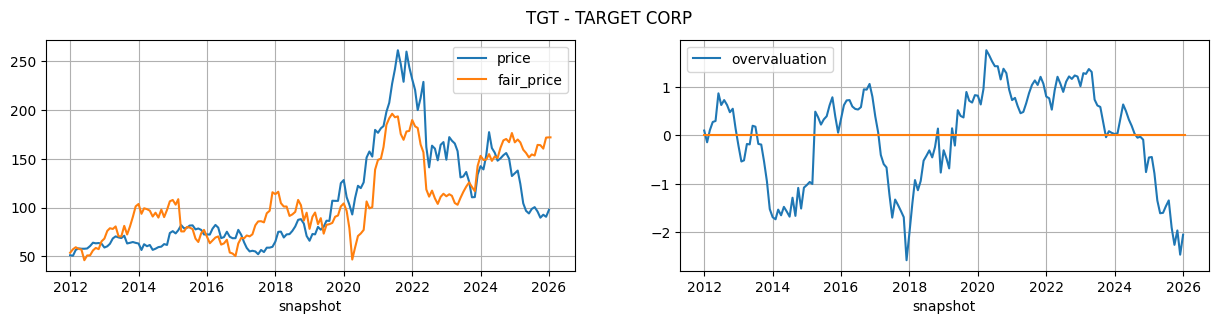

TGT fair_price = 4.946 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -151.0166


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.66327,1.547927,63.675902,163.925239
2025-11-01,0000027419,2025-08-02,TGT,57.851,42.431,6.386,1.66327,1.434790,62.953409,160.351776
2025-12-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.66327,1.468113,65.236234,171.642659
2026-01-01,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.66327,1.475507,65.286321,171.890392
2026-01-17,0000027419,2025-11-01,TGT,59.991,44.490,6.774,1.66327,1.475507,65.286321,171.890392


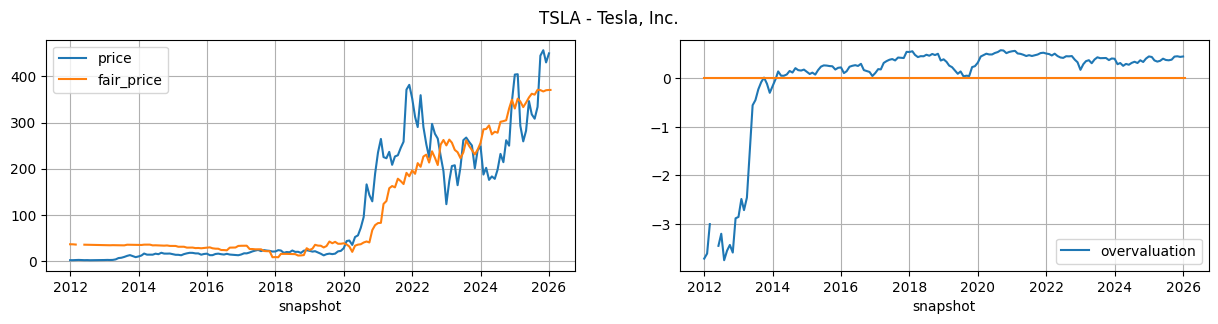

TSLA fair_price = 5.072 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 34.866


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001318605,2025-06-30,TSLA,128.567,51.253,15.765,0.723117,1.547927,66.119115,370.225001
2025-11-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.723117,1.434790,65.536188,367.268369
2025-12-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.723117,1.468113,66.060956,369.930013
2026-01-01,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.723117,1.475507,66.177398,370.520611
2026-01-17,0001318605,2025-09-30,TSLA,133.735,53.765,15.748,0.723117,1.475507,66.177398,370.520611


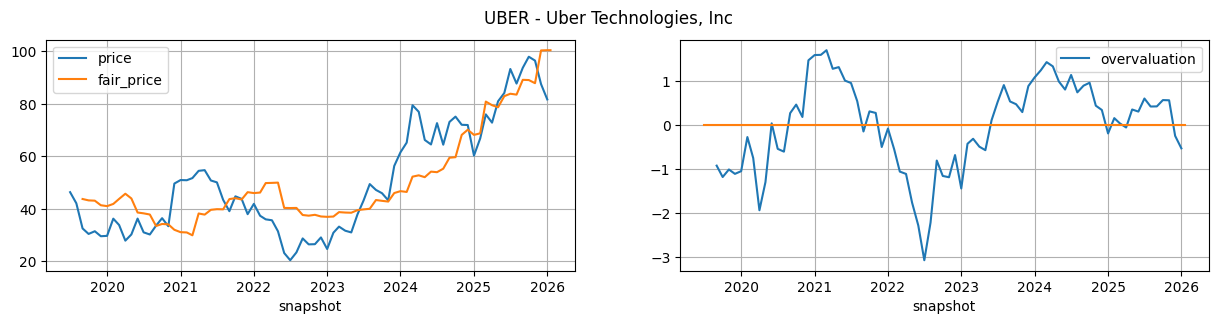

UBER fair_price = 1.2044 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 6.3524


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.580402,1.547927,68.694817,89.090202
2025-11-01,0001543151,2025-06-30,UBER,55.982,33.384,8.789,1.580402,1.434790,67.700455,87.892567
2025-12-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.580402,1.468113,78.062108,100.372405
2026-01-01,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.580402,1.475507,78.128403,100.452253
2026-01-17,0001543151,2025-09-30,UBER,63.344,35.210,8.966,1.580402,1.475507,78.128403,100.452253


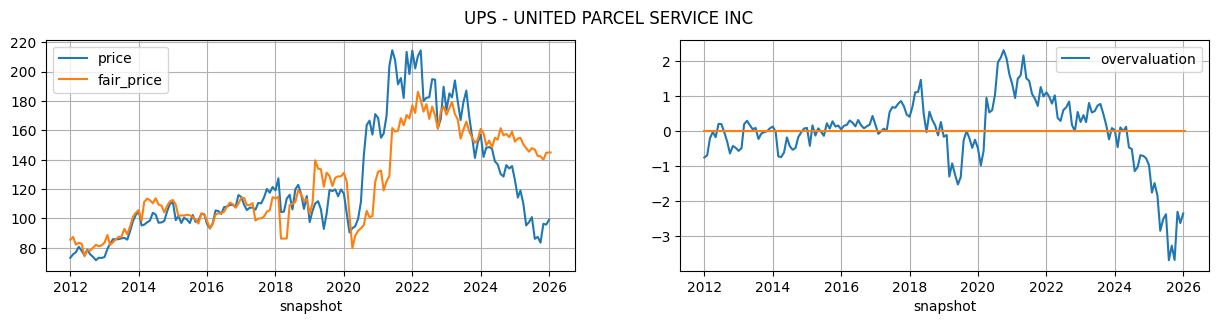

UPS fair_price = 2.7795 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 93.4943


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.862738,1.547927,17.591894,142.391674
2025-11-01,0001090727,2025-06-30,UPS,70.923,55.173,7.479,0.862738,1.434790,16.745742,140.039759
2025-12-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.862738,1.468113,18.448210,144.771837
2026-01-01,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.862738,1.475507,18.510786,144.945770
2026-01-17,0001090727,2025-09-30,UPS,71.392,55.569,8.463,0.862738,1.475507,18.510786,144.945770


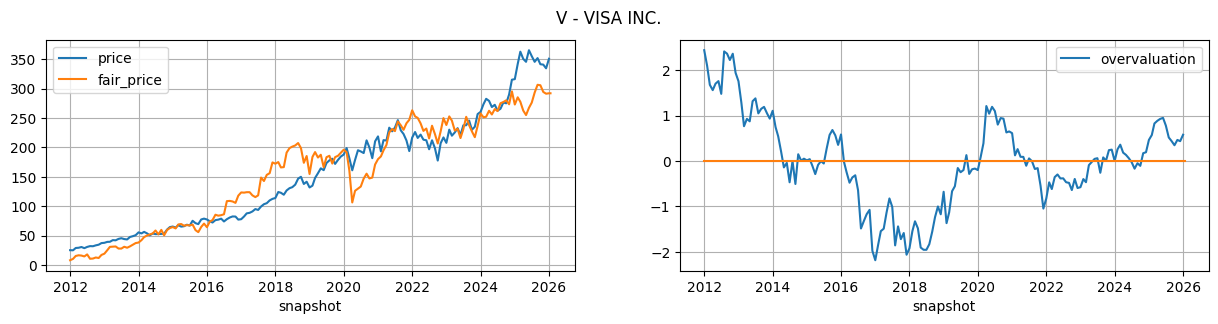

V fair_price = 4.2809 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -124.2823


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.254094,1.547927,100.432603,305.662785
2025-11-01,0001403161,2025-06-30,V,100.024,61.360,23.485,1.254094,1.434790,97.775578,294.288241
2025-12-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.254094,1.468113,97.076873,291.297132
2026-01-01,0001403161,2025-09-30,V,99.627,61.718,23.059,1.254094,1.475507,97.247373,292.027031
2026-01-17,0001403161,2025-09-30,V,99.627,61.718,23.059,1.254094,1.475507,97.247373,292.027031


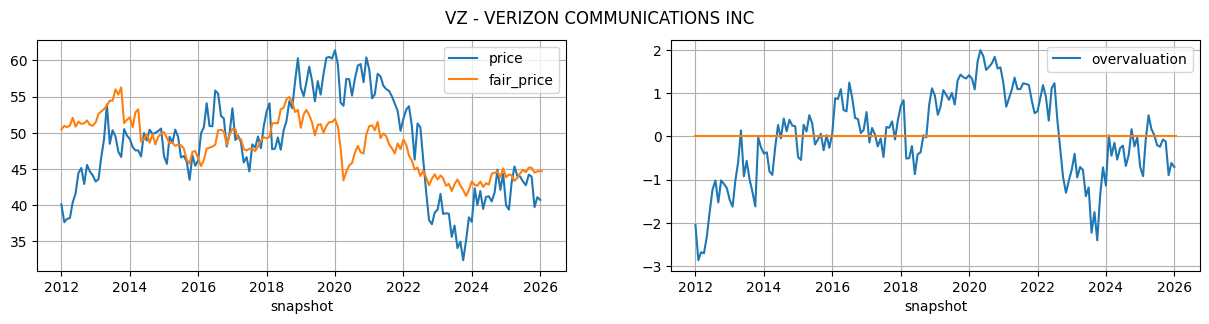

VZ fair_price = 0.1321 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 71.8082


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,0.051685,1.547927,-201.685836,45.170731
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.051685,1.434790,-206.740280,44.503170
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.051685,1.468113,-205.458852,44.672413
2026-01-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.051685,1.475507,-205.174513,44.709967
2026-01-17,0000732712,2025-09-30,VZ,388.331,281.986,38.455,0.051685,1.475507,-205.174513,44.709967


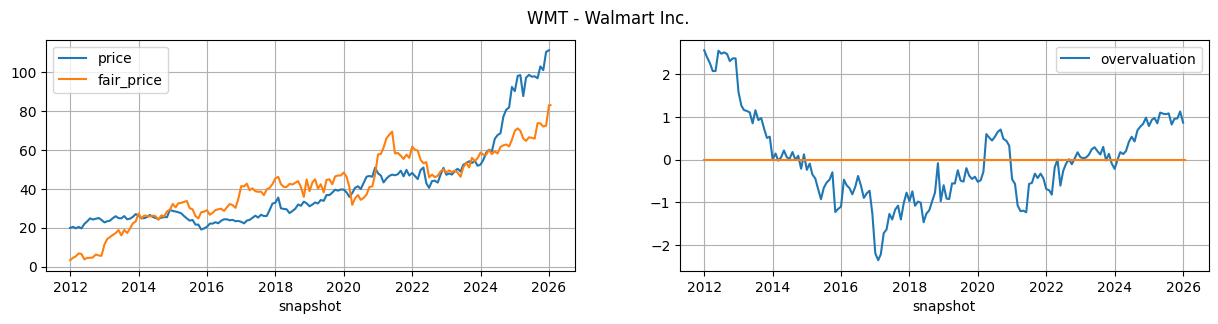

WMT fair_price = 0.3843 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm)  -85.6331


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.978667,1.547927,414.668528,73.738493
2025-11-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.978667,1.434790,410.319763,72.067112
2025-12-01,0000104169,2025-07-31,WMT,270.837,180.727,38.438,1.978667,1.468113,411.600625,72.559392
2026-01-01,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.978667,1.475507,439.053044,83.110312
2026-01-17,0000104169,2025-10-31,WMT,288.655,192.561,40.977,1.978667,1.475507,439.053044,83.110312


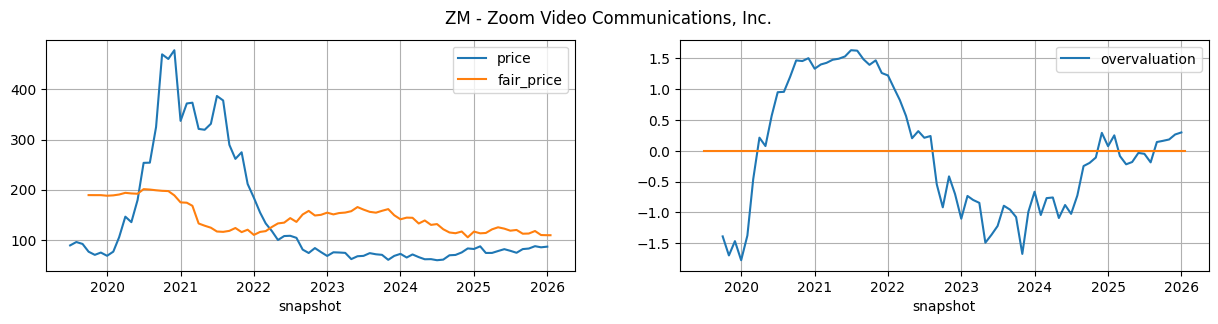

ZM fair_price = -23.2621 * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) + 189.6673


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,asmul,cashmul,fair_model,fair_price
snapshot,cik,,,,,,,,,
2025-10-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.222015,1.547927,3.319124,112.457626
2025-11-01,0001585521,2025-07-31,ZM,11.044063,2.093986,1.912984,0.222015,1.434790,3.102695,117.492221
2025-12-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.222015,1.468113,3.447944,109.461023
2026-01-01,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.222015,1.475507,3.463169,109.106856
2026-01-17,0001585521,2025-10-31,ZM,11.390811,2.103971,2.059093,0.222015,1.475507,3.463169,109.106856


In [18]:
sample_tickers = ["AAPL","ADBE","ADSK","AMD","AMZN","BYND","CAT","COIN","COST","CRSR","CSCO",
                "DIS","ENPH","F","FDX","FSLR","GM","GME","GOOG","GPRO","IBM","ILMN","INTC","IRBT","JNJ","KO"
                "LYFT","META","MMM","MRNA","MSFT","MU","NFLX","NKE","NVDA","ORCL","PFE","PINS","PLTR","PTON","PYPL",
                "ROKU","RUN","T","TDOC","TGT","TLRY","TSLA","UBER","UPS","V","VZ","WMT","ZM"]

market_median_asmul = result['asmul'].groupby(by=['snapshot']).median().rename('market_median_asmul')

def plot_ticker(a_group):
    (ticker, cik), df = a_group
    try:
        name = tickers.loc[cik]['name']
    except:
        name = ""

    df = df.reset_index().set_index('snapshot')

    # The asset and cash multipliers are not available for the most recent snapshots,
    # which are not part of the stock prices dataset.
    # We use the last available cash multiplier for the fair price calculation
    df['asmul'] = df['asmul'].interpolate()
    df['cashmul'] = df['cashmul'].interpolate()
    df['fair_model'] = df['asmul'] * df['Assets'] - df['Liabilities'] + df['cashmul']*df['NetCashOperating_ttm']

    # The model values and the price correlate by design, so the simplest linear regression will yield
    # conversion between our re-calculated model and the fair price.
    train_data = df[['model','price']].dropna()
    regressor = linear_model.LinearRegression().fit(X=train_data[['model']],y=train_data['price'])
    fair_model = df[['fair_model']].dropna()
    df['fair_price'] = 0.0
    if not fair_model.empty:
        df['fair_price'] = pd.Series(regressor.predict(fair_model.rename(columns={'fair_model':'model'})),
                                     index=fair_model.index)
    else:
        df['fair_price'] = None

    df['overvaluation'] = -1 * preprocessing.scale(df['fair_price']/df['price'])

    fig, (ax1, ax2) = plt.subplots(1,2)
    fig.suptitle(f"{ticker} - {name}")
    fig.set_size_inches(15,5)
    df[['price','fair_price']].plot(ax=ax1, grid=True, legend=True)
    df['overvaluation'].plot(ax=ax2, grid=True, legend=True, figsize=(15,3))
    pd.Series([0.0]*len(df.index),index=df.index).plot(ax=ax2,grid=True)
    plt.show()

    # Here we spell out our pricing model explicitly
    print("{} fair_price = {} * (asmul * Assets - Liabilities + cashmul * NetCashOperating_ttm) {} {}".format(
        ticker, regressor.coef_[0].round(4), "+" if regressor.intercept_ >= 0 else "", regressor.intercept_.round(4)
    ))
    df = df.reset_index().set_index(['snapshot','cik'])
    display(df.tail(5).dropna(axis='columns'))

    return df

plot_output = pd.concat(list(map(plot_ticker, 
                                 result[result['ticker'].isin(sample_tickers)].groupby(by=['ticker','cik']))))

The model has a lot of room for improvement. It is easy to notice that for some stocks it produces anomalies that should be investigated further. They are probably caused by shifting corporate accounting practices over time, or there could be logical errors in the processing pipeline, which produces the SEC fundamentals dataset.

The biggest advantage of the model, however, is that its results are completely explainable.

In [19]:
# Reality check for our fair price calculation: compute its correlation with the actual prices
print(plot_output[['price','fair_price']].corr())
# Sample data
plot_output[plot_output['ticker']=='VZ']

               price  fair_price
price       1.000000    0.920575
fair_price  0.920575    1.000000


,,date,ticker,Assets,Liabilities,NetCashOperating_ttm,price,asmul,cashmul,model,fair_model,fair_price,overvaluation
snapshot,cik,,,,,,,,,,,,
2012-01-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,40.12,0.051685,-1.109959,-161.764663,-161.764663,50.443280,-2.052208
2012-02-01,0000732712,2011-09-30,VZ,228.032,140.517,29.761,37.66,0.051685,-0.973899,-157.715371,-157.715371,50.978086,-2.864155
2012-03-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.11,0.051685,-0.898071,-159.386190,-159.386190,50.757414,-2.680626
2012-04-01,0000732712,2011-12-31,VZ,230.461,144.553,29.780,38.23,0.051685,-0.832869,-157.444478,-157.444478,51.013864,-2.701930
2012-05-01,0000732712,2012-03-31,VZ,222.921,134.500,30.702,40.38,0.051685,-0.860210,-149.388515,-149.388515,52.077847,-2.325167
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-01,0000732712,2025-06-30,VZ,383.285,278.924,37.100,43.95,0.051685,1.547927,-201.685836,-201.685836,45.170731,-0.117506
2025-11-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,39.74,0.051685,1.434790,-206.740280,-206.740280,44.503170,-0.893655
2025-12-01,0000732712,2025-09-30,VZ,388.331,281.986,38.455,41.11,0.051685,1.468113,-205.458852,-205.458852,44.672413,-0.613796


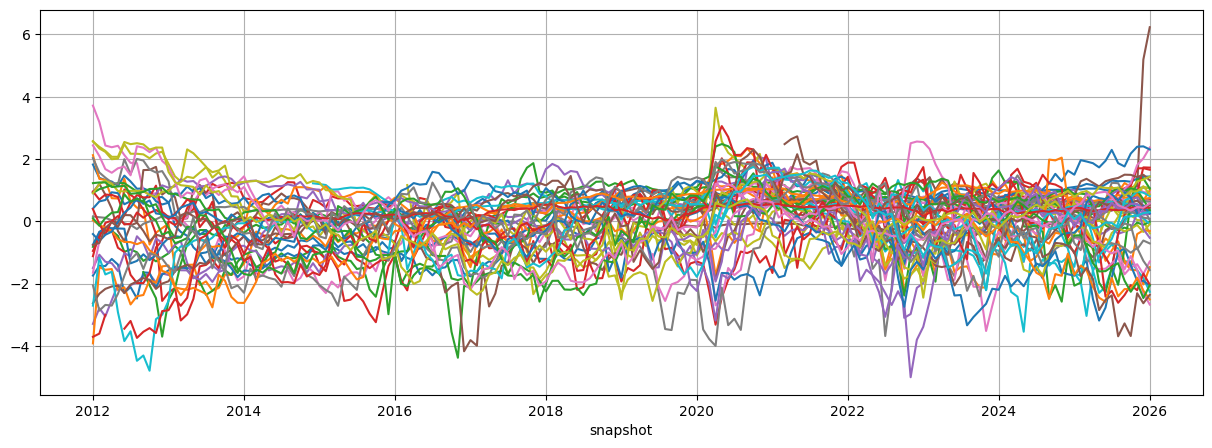

In [20]:
# All overvaluation sequences are scaled, therefore directly comparable
pd.pivot_table(plot_output, index='snapshot',columns='ticker',values='overvaluation').plot(
    grid=True, legend=False, figsize=(15,5))
plt.show()

In [21]:
print('Done without errors')

Done without errors


DISCLAIMER: The results of this model must not in any way be interpreted as financial advice. It is intended for research purposes only and no investment decisions must be made based on it.